In [1]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from sklearn_extra.cluster import CLARA

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#load embedding matrices
t1_euclidean_embeddings  = np.load('../exps/eval_t1_hierarchical_split/euclidean/hyp_embeddings.npy', allow_pickle=True)
t1_euclidean_labels      = np.load('../exps/eval_t1_hierarchical_split/euclidean/hyp_labels.npy', allow_pickle=True)
t1_euclidean_match_flags = np.load('../exps/eval_t1_hierarchical_split/euclidean/hyp_match_flags.npy', allow_pickle=True)

t2_euclidean_embeddings  = np.load('../exps/eval_t2_ft_hierarchical_split/euclidean/hyp_embeddings.npy', allow_pickle=True)
t2_euclidean_labels      = np.load('../exps/eval_t2_ft_hierarchical_split/euclidean/hyp_labels.npy', allow_pickle=True)
t2_euclidean_match_flags = np.load('../exps/eval_t2_ft_hierarchical_split/euclidean/hyp_match_flags.npy', allow_pickle=True)

t3_euclidean_embeddings  = np.load('../exps/eval_t3_ft_hierarchical_split/euclidean/hyp_embeddings.npy', allow_pickle=True)
t3_euclidean_labels      = np.load('../exps/eval_t3_ft_hierarchical_split/euclidean/hyp_labels.npy', allow_pickle=True)
t3_euclidean_match_flags = np.load('../exps/eval_t3_ft_hierarchical_split/euclidean/hyp_match_flags.npy', allow_pickle=True)

t4_euclidean_embeddings  = np.load('../exps/eval_t4_ft_hierarchical_split/euclidean/hyp_embeddings.npy', allow_pickle=True)
t4_euclidean_labels      = np.load('../exps/eval_t4_ft_hierarchical_split/euclidean/hyp_labels.npy', allow_pickle=True)
t4_euclidean_match_flags = np.load('../exps/eval_t4_ft_hierarchical_split/euclidean/hyp_match_flags.npy', allow_pickle=True)

superclass_map = {0:'vehicle', 1:'vehicle', 2:'outdoor', 3:'outdoor', 4:'animal', 5:'animal', 6:'animal', 7:'accessory', 8:'sports', 9:'sports', 10:'kitchen', 
                  11:'kitchen',12:'food', 13:'food', 14:'furniture', 15:'furniture', 16:'electronic', 17:'appliance',  18:'appliance', 19:'indoor', #end task 1 

                  20:'person', 21:'vehicle', 22:'vehicle', 23:'outdoor', 24:'animal', 25:'animal', 26:'accessory', 27:'sports', 28:'sports', 29:'kitchen',
                  30:'food',  31:'food', 32:'food',  33:'furniture', 34:'furniture', 35:'electronic', 36:'electronic', 37:'appliance',  38:'indoor', 39:'indoor', #end task 2

                  40: 'vehicle', 41: 'vehicle', 42: 'outdoor', 43: 'animal', 44: 'animal', 45: 'animal', 46: 'accessory', 47: 'sports', 48: 'sports', 49: 'sports', 50: 'kitchen',
                  51: 'kitchen', 52: 'food', 53: 'food', 54: 'kitchen', 55: 'electronic', 56: 'electronic', 57: 'appliance', 58: 'indoor', 59: 'indoor',#end task 3

                  60: 'vehicle', 61: 'vehicle', 62: 'outdoor', 63: 'animal', 64: 'animal', 65: 'accessory', 66: 'accessory', 67: 'sports', 68: 'sports', 69: 'sports', 
                  70: 'kitchen', 71: 'kitchen', 72: 'food', 73: 'food', 74: 'food', 75: 'kitchen', 76: 'electronic', 77: 'appliance', 78: 'indoor', 79: 'indoor' #end task 4
                  }

#*****************************T1********************************************
t1_emb_euclidean         = t1_euclidean_embeddings.reshape(-1, 256)
t1_labels_euclidean      = t1_euclidean_labels.reshape(-1)
t1_match_flags_euclidean = t1_euclidean_match_flags.reshape(-1)

t1_euclidean_embeddings_matched = t1_emb_euclidean[t1_match_flags_euclidean]
t1_euclidean_labels_matched = t1_labels_euclidean[t1_match_flags_euclidean]

t1_euclidean_emb_mask = t1_euclidean_labels_matched != 80 
t1_euclidean_labels_known = t1_euclidean_labels_matched[t1_euclidean_emb_mask]
t1_euclidean_embeddings_known = t1_euclidean_embeddings_matched[t1_euclidean_emb_mask]
#*****************************T2********************************************
t2_emb_euclidean         = t2_euclidean_embeddings.reshape(-1, 256)
t2_labels_euclidean      = t2_euclidean_labels.reshape(-1)
t2_match_flags_euclidean = t2_euclidean_match_flags.reshape(-1)

t2_euclidean_embeddings_matched = t2_emb_euclidean[t2_match_flags_euclidean]
t2_euclidean_labels_matched = t2_labels_euclidean[t2_match_flags_euclidean]

t2_euclidean_emb_mask = t2_euclidean_labels_matched != 80 
t2_euclidean_labels_known = t2_euclidean_labels_matched[t2_euclidean_emb_mask]
t2_euclidean_embeddings_known = t2_euclidean_embeddings_matched[t2_euclidean_emb_mask]
#***********************************T3**************************************
t3_emb_euclidean                 = t3_euclidean_embeddings.reshape(-1, 256)
t3_labels_euclidean              = t3_euclidean_labels.reshape(-1)
t3_match_flags_euclidean         = t3_euclidean_match_flags.reshape(-1)

t3_euclidean_embeddings_matched  = t3_emb_euclidean[t3_match_flags_euclidean]
t3_euclidean_labels_matched      = t3_labels_euclidean[t3_match_flags_euclidean]

t3_euclidean_emb_mask            = t3_euclidean_labels_matched != 80 
t3_euclidean_labels_known        = t3_euclidean_labels_matched[t3_euclidean_emb_mask]
t3_euclidean_embeddings_known    = t3_euclidean_embeddings_matched[t3_euclidean_emb_mask]
#***********************************T4**************************************
t4_emb_euclidean                 = t4_euclidean_embeddings.reshape(-1, 256)
t4_labels_euclidean              = t4_euclidean_labels.reshape(-1)
t4_match_flags_euclidean         = t4_euclidean_match_flags.reshape(-1)

t4_euclidean_embeddings_matched  = t4_emb_euclidean[t4_match_flags_euclidean]
t4_euclidean_labels_matched      = t4_labels_euclidean[t4_match_flags_euclidean]

t4_euclidean_emb_mask            = t4_euclidean_labels_matched != 80 
t4_euclidean_labels_known        = t4_euclidean_labels_matched[t4_euclidean_emb_mask]
t4_euclidean_embeddings_known    = t4_euclidean_embeddings_matched[t4_euclidean_emb_mask]

In [3]:
prototype_bank = dict()
replay_buffer = dict()

#set limits for replay buffer
num_samples = 1000
rep_frac = 0.7
hard_frac = 1 - rep_frac

#rng
seed=42

#shots
shot_size=10

#samples
rep_samples  = int(rep_frac * num_samples)
hard_samples = int(hard_frac * num_samples)

def map_to_superclasses(labels, superclass_map):
    return np.array([superclass_map[int(y)] for y in labels], dtype=object)

def l2_normalize(x):
    return x / (np.linalg.norm(x, axis=1, keepdims=True))

def cosine_loss(a, b, axis=-1):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)

    dot = np.sum(a * b, axis=axis)
    norm_a = np.linalg.norm(a, axis=axis)
    norm_b = np.linalg.norm(b, axis=axis)

    cos_sim = dot / (norm_a * norm_b)
    return 1.0 - cos_sim

In [4]:
def rep_items(X, centers):
    chosen = []
    used = set()

    for center in centers:
        dists = cosine_loss(X, center, axis=1)
        order = np.argsort(dists)
        for idx in order:
            if idx not in used:
                used.add(idx)
                chosen.append(idx)
                break
    return np.array(chosen, dtype=int)

def select_representative_examples(class_emb, budget):
    rep = max(1, int(rep_frac * budget))

    if len(class_emb) <= rep:
        return class_emb.copy()

    k_eff = min(rep, len(class_emb))
    km = CLARA(n_clusters=k_eff, random_state=seed, metric="cosine")
    km.fit(class_emb)

    rep_idx = rep_items(class_emb, km.cluster_centers_)

    return class_emb[rep_idx]

def select_hard_examples(class_emb, class_num, prototypes, budget):
    hard = max(1, int(hard_frac * budget))

    if len(class_emb) <= hard:
        return class_emb.copy()

    margins = hard_scores(class_emb, class_num, prototypes)
    hard_idx = np.argsort(margins)[:hard]

    return class_emb[hard_idx]

def hard_scores(class_emb, class_num, prototypes):
    true_protos = prototypes[class_num]
    d_true = np.min(cosine_loss(class_emb[:, None, :], true_protos[None, :, :], axis=2), axis=1)

    d_wrong = np.full(len(class_emb), np.inf)

    for other_cls, other_protos in prototypes.items():
        if other_cls == class_num:
            continue
        d_cls = np.min(cosine_loss(class_emb[:, None, :], other_protos[None, :, :], axis=2),axis=1)
        d_wrong = np.minimum(d_wrong, d_cls)

    margins = d_wrong - d_true
    return margins

def update_replay_buffer(support_emb, support_class_labels, support_sc_labels, prototype_bank, replay_buffer, superclass_list):
    new_buffer = {k: v.copy() for k, v in replay_buffer.items()}
    sc_to_classes = {}

    for cls in np.unique(support_class_labels):
        sc = superclass_map[int(cls)]
        sc_to_classes.setdefault(sc, set()).add(int(cls))

    for cls_key in new_buffer:
        sc = superclass_map[int(cls_key)]
        sc_to_classes.setdefault(sc, set()).add(int(cls_key))

    for superclass in superclass_list:
        classes_in_sc = sorted(sc_to_classes.get(superclass, set()))
        if not classes_in_sc:
            continue

        budget_per_class = max(1, num_samples // len(classes_in_sc))

        for cls in classes_in_sc:
            cls_emb = support_emb[support_class_labels == cls]

            parts = []
            if cls in new_buffer and len(new_buffer[cls]) > 0:
                parts.append(new_buffer[cls])

            if len(cls_emb) > 0:
                rep = select_representative_examples(cls_emb, budget_per_class)
                if len(rep) > 0:
                    parts.append(rep)
                if len(prototype_bank) > 1 and hard_samples > 0:
                    hard = select_hard_examples(cls_emb, superclass, prototype_bank, budget_per_class)
                    if len(hard) > 0:
                        parts.append(hard)

            if not parts:
                continue

            combined = np.vstack(parts)
            combined = np.unique(combined, axis=0)
            if len(combined) > budget_per_class:
                combined = combined[:budget_per_class]

            new_buffer[cls] = combined

    return new_buffer

In [5]:
def split_data(emb, class_labels):
    rng = np.random.default_rng(seed)
    unique_classes = np.unique(class_labels)
    sc_to_classes = {}

    for cls in unique_classes:
        sc = superclass_map[int(cls)]
        sc_to_classes.setdefault(sc, []).append(cls)

    class_idx = {}
    for cls in unique_classes:
        idx = np.where(class_labels == cls)[0]
        rng.shuffle(idx)
        n_support = min(shot_size, max(1, len(idx) - 1))
        class_idx[cls] = {'support': idx[:n_support], 'remaining': idx[n_support:]}

    sc_available = {sc: sum(len(class_idx[c]['remaining']) for c in classes) for sc, classes in sc_to_classes.items()}
    target_per_sc = max(1, int(np.median(list(sc_available.values()))))

    support_x, support_class_list = [], []
    query_x,   query_class_list   = [], []

    for sc, classes in sc_to_classes.items():
        base_q = max(1, target_per_sc // len(classes))

        for cls in classes:
            remaining  = class_idx[cls]['remaining']
            n_query    = min(base_q, len(remaining))
            
            if n_query <= 0:
                continue

            support_x.append(emb[class_idx[cls]['support']])
            support_class_list.append(np.full(len(class_idx[cls]['support']), cls))

            query_x.append(emb[remaining[:n_query]])
            query_class_list.append(np.full(n_query, cls))

    support_x         = np.concatenate(support_x)
    support_class_arr = np.concatenate(support_class_list)
    query_x           = np.concatenate(query_x)
    query_class_arr   = np.concatenate(query_class_list)

    support_superclass = map_to_superclasses(support_class_arr, superclass_map)
    query_superclass   = map_to_superclasses(query_class_arr,   superclass_map)

    return support_x, support_class_arr, support_superclass, query_x, query_class_arr, query_superclass

In [6]:
def create_superclass_prototypes(support_emb, support_sc_labels, replay_buffer, superclass_list, k):
    global prototype_bank

    for sc in superclass_list:
        current_mem = []

        for cls_key, cls_emb in replay_buffer.items():
            if superclass_map[int(cls_key)] == sc and len(cls_emb) > 0:
                current_mem.append(cls_emb)

        current_support = support_emb[support_sc_labels == sc]
        if len(current_support) > 0:
            current_mem.append(current_support)

        if not current_mem:
            continue

        support_2d = np.vstack(current_mem)
        k_eff = min(k, len(support_2d))
        model = CLARA(n_clusters=k_eff, metric="cosine", random_state=seed)
        model.fit(support_2d)
        prototype_bank[sc] = model.cluster_centers_

def predict_superclass(query, prototype_bank):
    pred_sc = None
    min_dist = float("inf")

    for sc, proto_list in prototype_bank.items():
        dist = [cosine_loss(query, proto) for proto in proto_list]
        min_sc_dist = np.min(dist)

        if min_sc_dist < min_dist:
            min_dist = min_sc_dist
            pred_sc = sc

    return pred_sc, min_dist

def batch_predict_superclass(query_emb, prototype_bank):
    preds, dists = [], []
    for q in query_emb:
        p, d = predict_superclass(q, prototype_bank)
        preds.append(p)
        dists.append(d)
    return np.array(preds, dtype=object), np.array(dists)

In [7]:
def superclass_accuracy_table(y_true_sc, y_pred_sc, superclass_map=None):
    y_true_sc = np.asarray(y_true_sc, dtype=object)
    y_pred_sc = np.asarray(y_pred_sc, dtype=object)

    rows = []
    for sc in sorted(np.unique(y_true_sc)):
        mask = (y_true_sc == sc)
        rows.append({"superclass": sc,
                     "n_query": int(mask.sum()),
                     "accuracy": float((y_pred_sc[mask] == y_true_sc[mask]).mean())})

    return pd.DataFrame(rows).sort_values(["accuracy", "n_query"], ascending=[True, False]).reset_index(drop=True)

In [8]:
def run_incremental_fewshot(tasks, k=3):
    global prototype_bank
    prototype_bank = {}
    replay_buffer  = {}

    seen_superclasses = []
    results           = []
    per_task_details  = []

    for task_id, (support_emb, support_class_labels, support_sc_labels,
                  query_emb,   query_class_labels,   query_sc_labels) in enumerate(tasks, start=1):

        task_superclasses = sorted(np.unique(np.concatenate([support_sc_labels, query_sc_labels])).tolist())
        seen_superclasses = sorted(set(seen_superclasses).union(task_superclasses))

        create_superclass_prototypes(support_emb=support_emb, support_sc_labels=support_sc_labels,
                                     replay_buffer=replay_buffer, superclass_list=seen_superclasses, k=k)

        preds_sc, dists = batch_predict_superclass(query_emb, prototype_bank)
        acc = np.mean(preds_sc == query_sc_labels) if len(query_sc_labels) > 0 else np.nan

        superclass_table = superclass_accuracy_table(query_sc_labels, preds_sc, superclass_map)

        results.append({"task": task_id, "accuracy": acc,
                        "num_seen_superclasses": len(seen_superclasses),
                        "macro_superclass_acc": superclass_table["accuracy"].mean(),
                        "superclass_acc_std":   superclass_table["accuracy"].std(ddof=0)})

        per_task_details.append({"task": task_id, "y_true": query_sc_labels.copy(),
                                 "y_pred": preds_sc.copy(), "dists": dists.copy(),
                                 "superclass_table": superclass_table})

        replay_buffer = update_replay_buffer(support_emb=support_emb,
                                             support_class_labels=support_class_labels,
                                             support_sc_labels=support_sc_labels,
                                             prototype_bank=prototype_bank,
                                             replay_buffer=replay_buffer,
                                             superclass_list=task_superclasses)

    return results, replay_buffer, per_task_details


def test_incremental_fewshot(tasks):
    results = []
    per_task_details = []
    seen_superclasses = sorted(prototype_bank.keys())

    for task_id, (emb, sc_labels) in enumerate(tasks, start=1):
        preds_sc, dists = batch_predict_superclass(emb, prototype_bank)
        acc = np.mean(preds_sc == sc_labels) if len(sc_labels) > 0 else np.nan

        superclass_table = superclass_accuracy_table(sc_labels, preds_sc, superclass_map)

        results.append({"task": task_id,
                        "accuracy": acc,
                        "num_seen_superclasses": len(seen_superclasses),
                        "macro_superclass_acc": superclass_table["accuracy"].mean(),
                        "superclass_acc_std": superclass_table["accuracy"].std(ddof=0)})

        per_task_details.append({"task": task_id,
                                 "y_true": sc_labels.copy(),
                                 "y_pred": preds_sc.copy(),
                                 "dists": dists.copy(),
                                 "superclass_table": superclass_table})

    return results, per_task_details

In [9]:
def superclass_labels(y, superclass_map=None):
    y = np.asarray(y)
    if y.dtype.kind in {"U", "S", "O"}:
        return y.astype(object)
    return np.array([superclass_map[int(x)] for x in y], dtype=object)

def normalized_confusion(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm = cm.astype(float)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums != 0)
    return pd.DataFrame(cm_norm, index=labels, columns=labels)

def superclass_confusion_table(y_true, y_pred, superclass_map=None):
    true_sc = superclass_labels(y_true, superclass_map)
    pred_sc = superclass_labels(y_pred, superclass_map)
    labels = sorted(np.unique(np.concatenate([true_sc, pred_sc])))
    return normalized_confusion(true_sc, pred_sc, labels)

def show_confusion_matrix_image(y_true, y_pred, superclass_map=None, title="Superclass Confusion Matrix"):
    cm_df = superclass_confusion_table(y_true, y_pred, superclass_map)
    cm = cm_df.values
    labels = cm_df.index.tolist()

    n = len(labels)
    fig_size = max(10, 0.9 * n + 2)

    fig, ax = plt.subplots(figsize=(fig_size, fig_size))
    im = ax.imshow(cm, vmin=0.0, vmax=1.0, interpolation="nearest")

    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted superclass")
    ax.set_ylabel("True superclass")
    ax.set_title(title)

    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.set_ylabel("Value", rotation=270, labelpad=15)

    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

def compact_summary_table(results, per_task_details):
    rows = []

    for r, d in zip(results, per_task_details):
        y_true = np.asarray(d["y_true"], dtype=object)
        y_pred = np.asarray(d["y_pred"], dtype=object)

        task_acc = float((y_true == y_pred).mean())

        sc_table = superclass_accuracy_table(y_true, y_pred)
        mean_acc = float(sc_table["accuracy"].mean())
        std_acc = float(sc_table["accuracy"].std(ddof=0))

        rows.append({"task": int(r["task"]),
                     "task_accuracy": task_acc,
                     "mean_superclass_acc": mean_acc,
                     "std_superclass_acc": std_acc})

    out = pd.DataFrame(rows)

    return out.round({"task_accuracy": 4,
                      "mean_superclass_acc": 4,
                      "std_superclass_acc": 4})

def print_task_report(per_task_details, idx):
    d = per_task_details[idx]

    print(f"\n================ TASK {idx + 1} ================")
    show_confusion_matrix_image(d["y_true"], d["y_pred"], title=f"Task {idx + 1} Superclass Confusion Matrix")

In [10]:
t1_support_emb, t1_support_class, t1_support_sc, t1_query_emb, t1_query_class, t1_query_sc = split_data(l2_normalize(t1_euclidean_embeddings_known), t1_euclidean_labels_known)
t2_support_emb, t2_support_class, t2_support_sc, t2_query_emb, t2_query_class, t2_query_sc = split_data(l2_normalize(t2_euclidean_embeddings_known), t2_euclidean_labels_known)
t3_support_emb, t3_support_class, t3_support_sc, t3_query_emb, t3_query_class, t3_query_sc = split_data(l2_normalize(t3_euclidean_embeddings_known), t3_euclidean_labels_known)
t4_support_emb, t4_support_class, t4_support_sc, t4_query_emb, t4_query_class, t4_query_sc = split_data(l2_normalize(t4_euclidean_embeddings_known), t4_euclidean_labels_known)

train_tasks = [(t1_support_emb, t1_support_class, t1_support_sc, t1_query_emb, t1_query_class, t1_query_sc),
               (t2_support_emb, t2_support_class, t2_support_sc, t2_query_emb, t2_query_class, t2_query_sc),
               (t3_support_emb, t3_support_class, t3_support_sc, t3_query_emb, t3_query_class, t3_query_sc),
               (t4_support_emb, t4_support_class, t4_support_sc, t4_query_emb, t4_query_class, t4_query_sc)]

test_tasks = [(t1_query_emb, t1_query_sc), (t2_query_emb, t2_query_sc), (t3_query_emb, t3_query_sc), (t4_query_emb, t4_query_sc)]

   task  task_accuracy  mean_superclass_acc  std_superclass_acc
0     1         0.8985               0.8946              0.0591
1     2         0.8027               0.7999              0.0643
2     3         0.7715               0.7727              0.0644
3     4         0.7345               0.7254              0.0999

================ TASK 1 ================


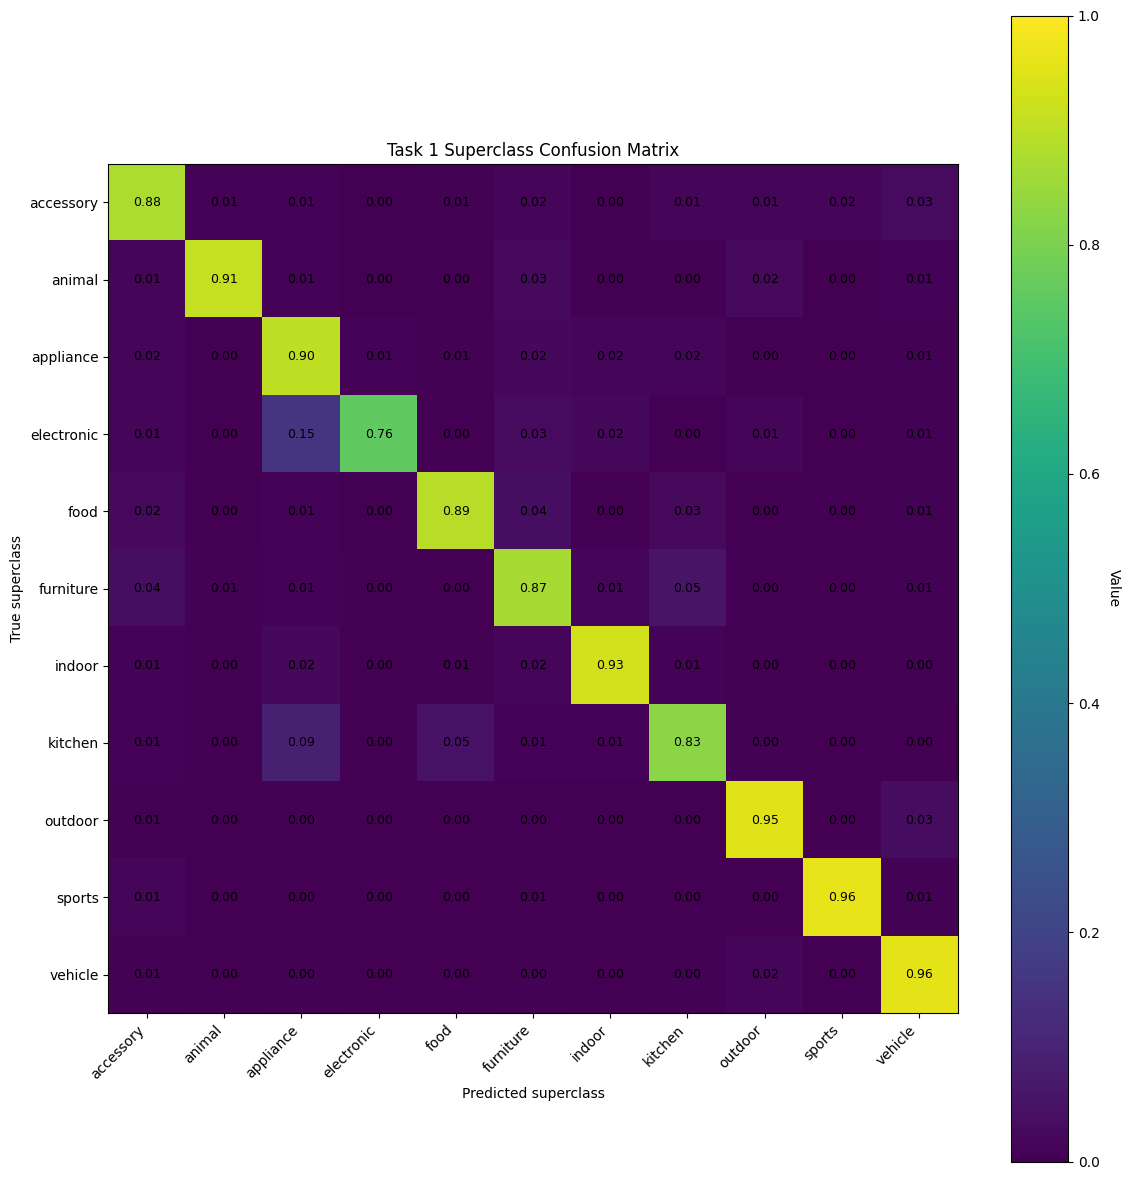


================ TASK 2 ================


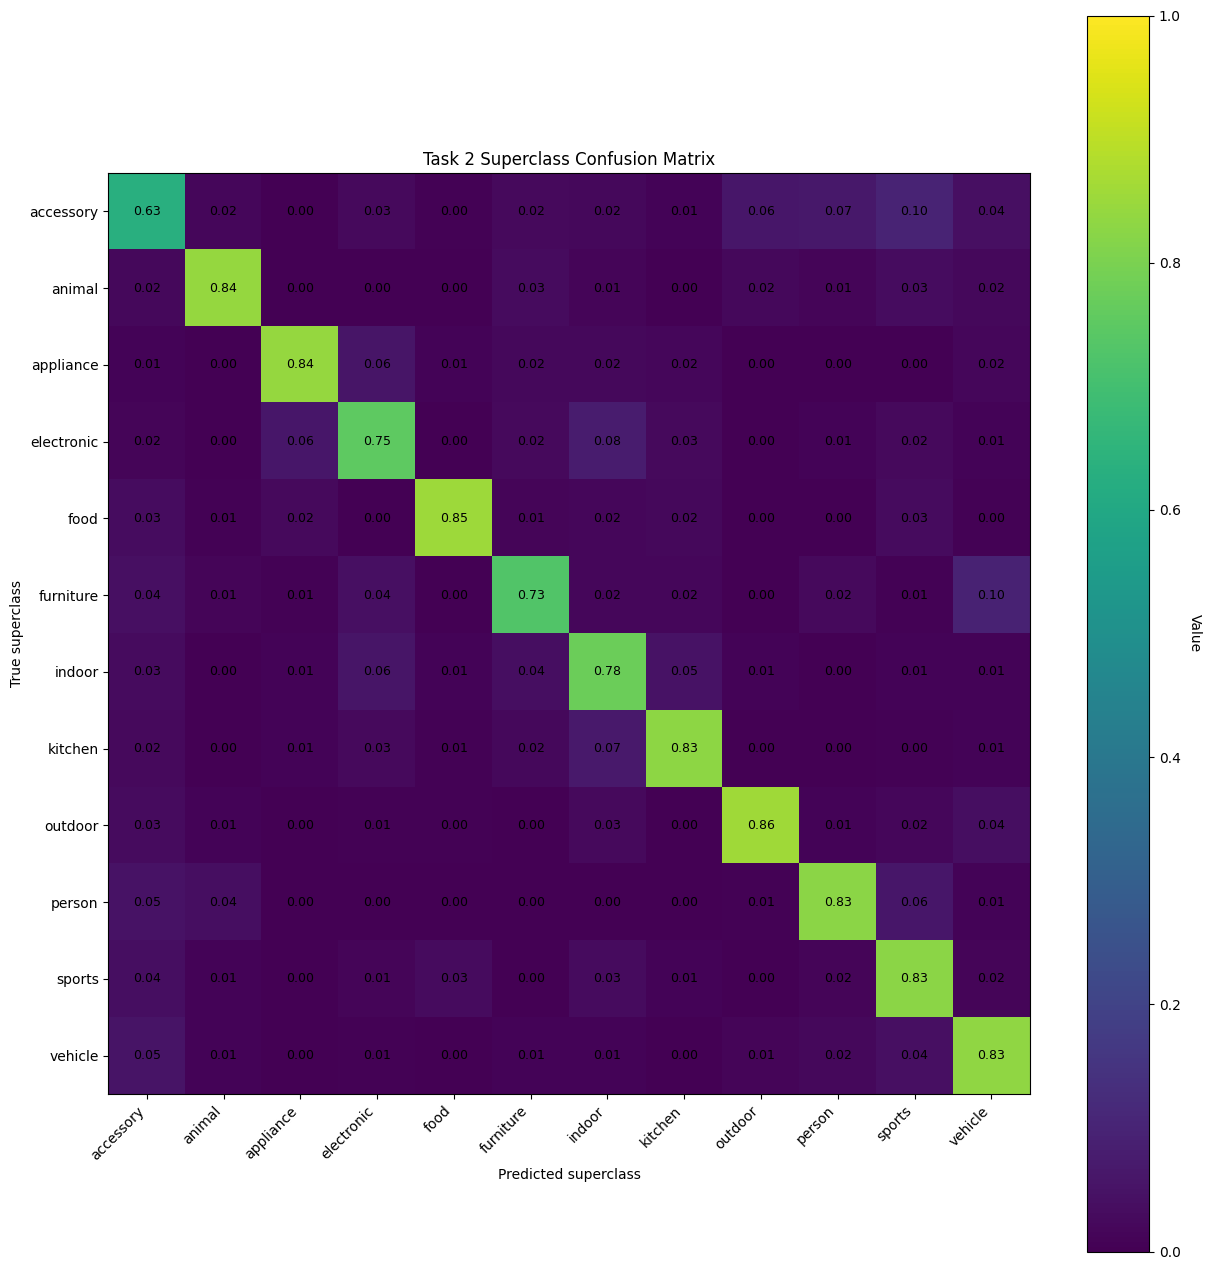


================ TASK 3 ================


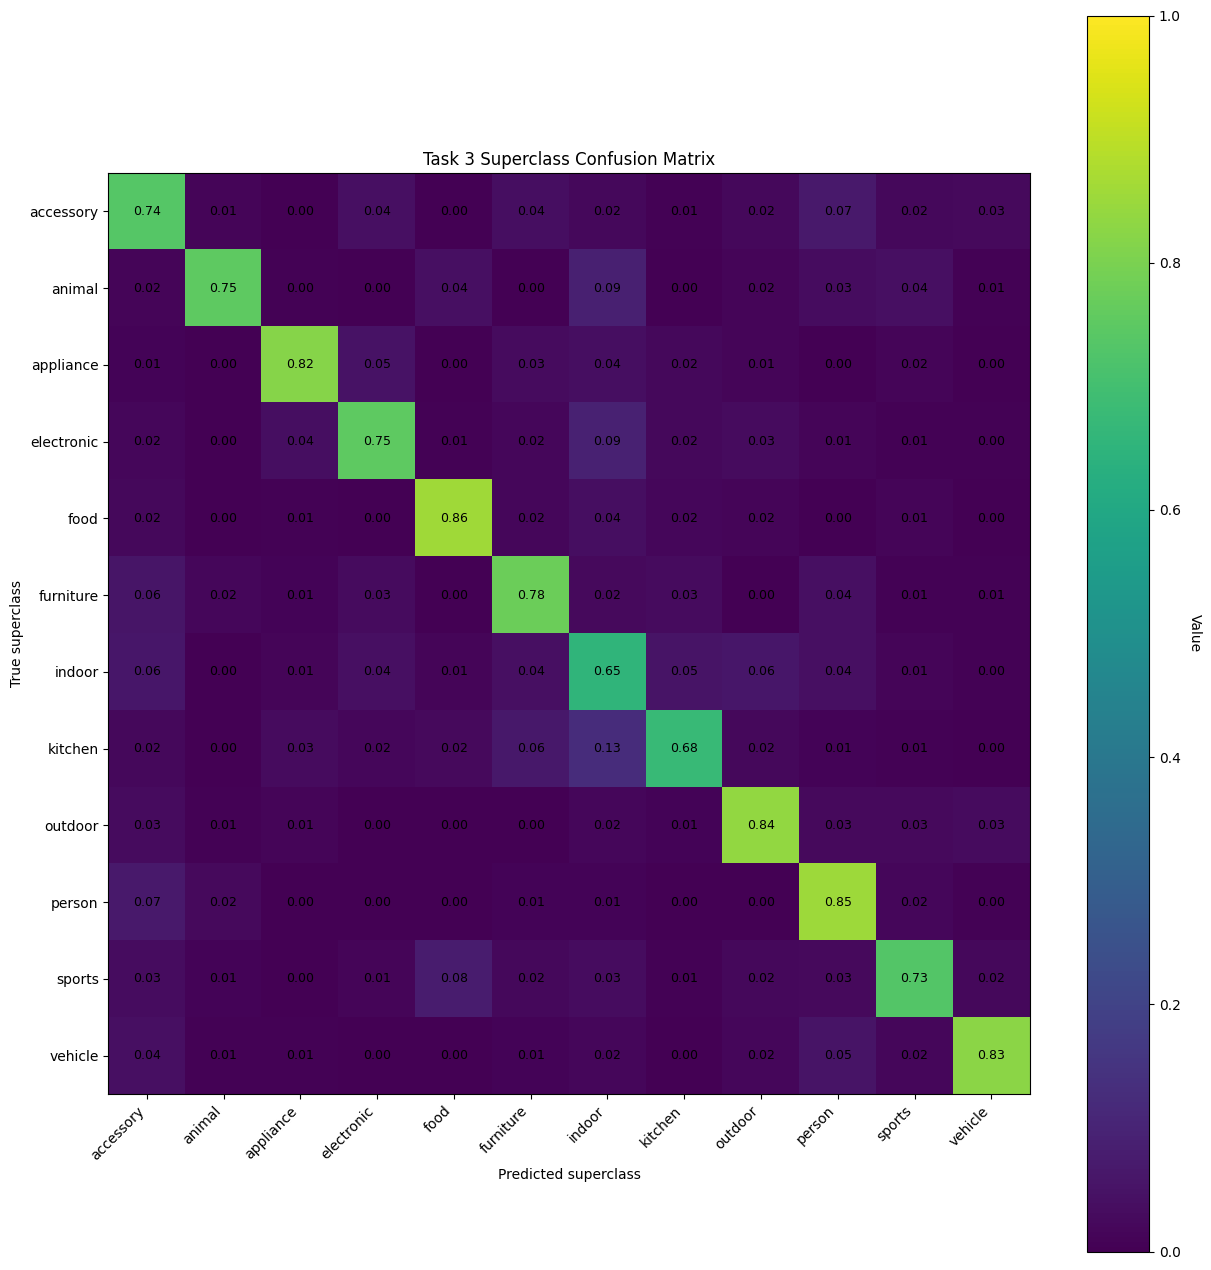


================ TASK 4 ================


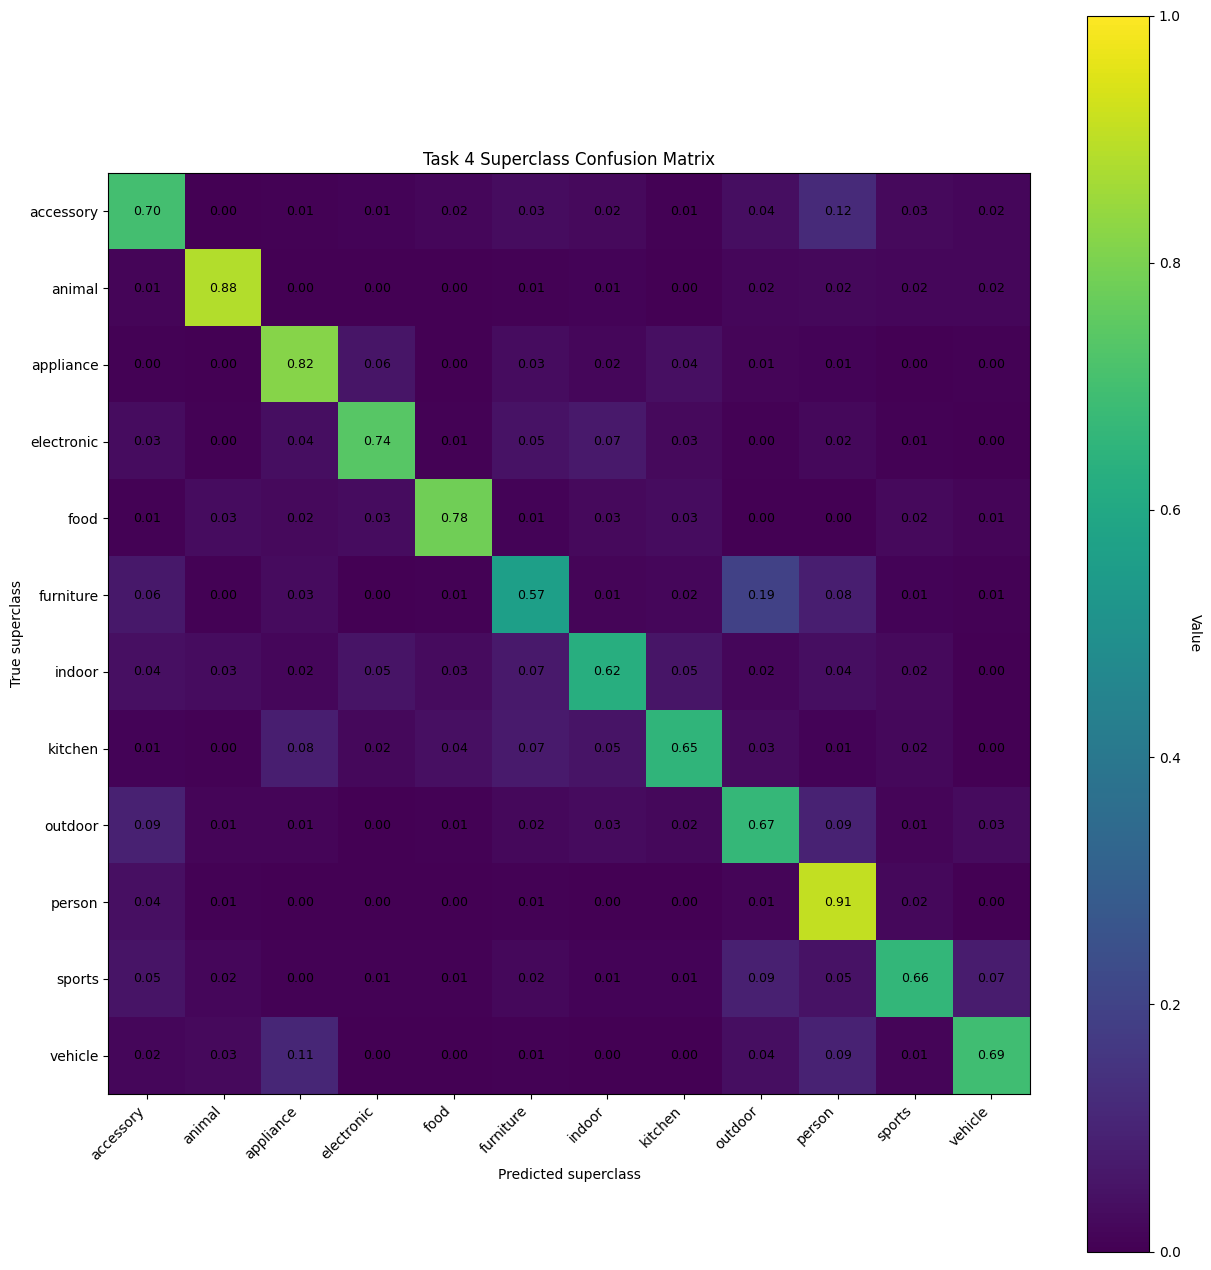

In [29]:
results, replay_buffer, per_task_details = run_incremental_fewshot(train_tasks, k=15)

summary_df = compact_summary_table(results, per_task_details)
print(summary_df)

for i in range(len(per_task_details)):
    print_task_report(per_task_details, i)

   task  task_accuracy  mean_superclass_acc  std_superclass_acc
0     1         0.8985               0.8946              0.0591

================ TASK 1 ================


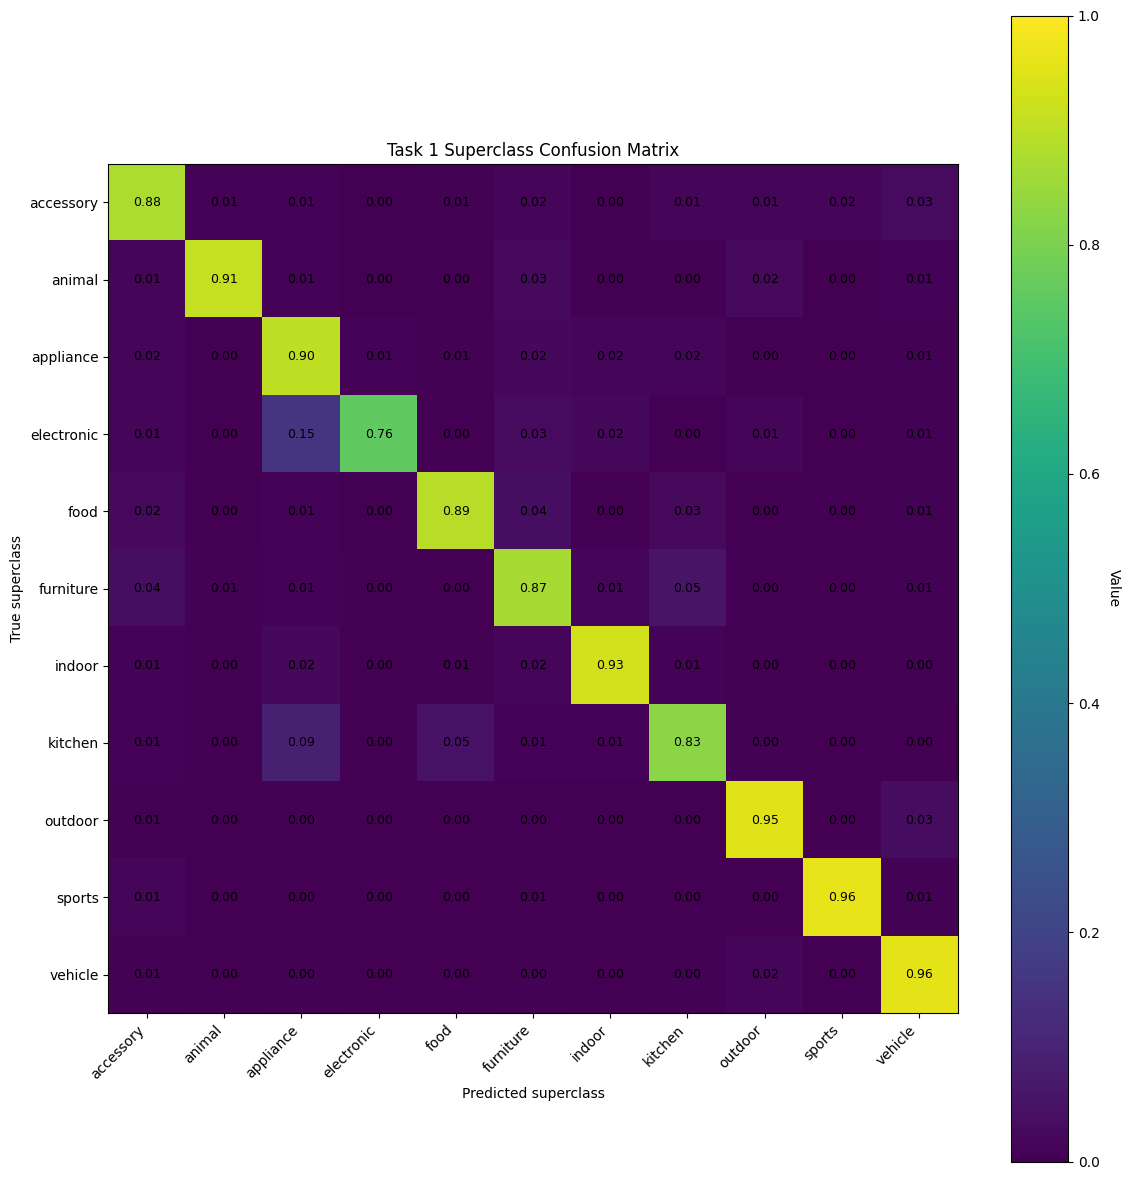

In [30]:
results, replay_buffer, per_task_details = run_incremental_fewshot(train_tasks[:1], k=15)

summary_df = compact_summary_table(results, per_task_details)
print(summary_df)

for i in range(len(per_task_details)):
    print_task_report(per_task_details, i)

   task  task_accuracy  mean_superclass_acc  std_superclass_acc
0     1         0.8653                0.871              0.0692

================ TASK 1 ================


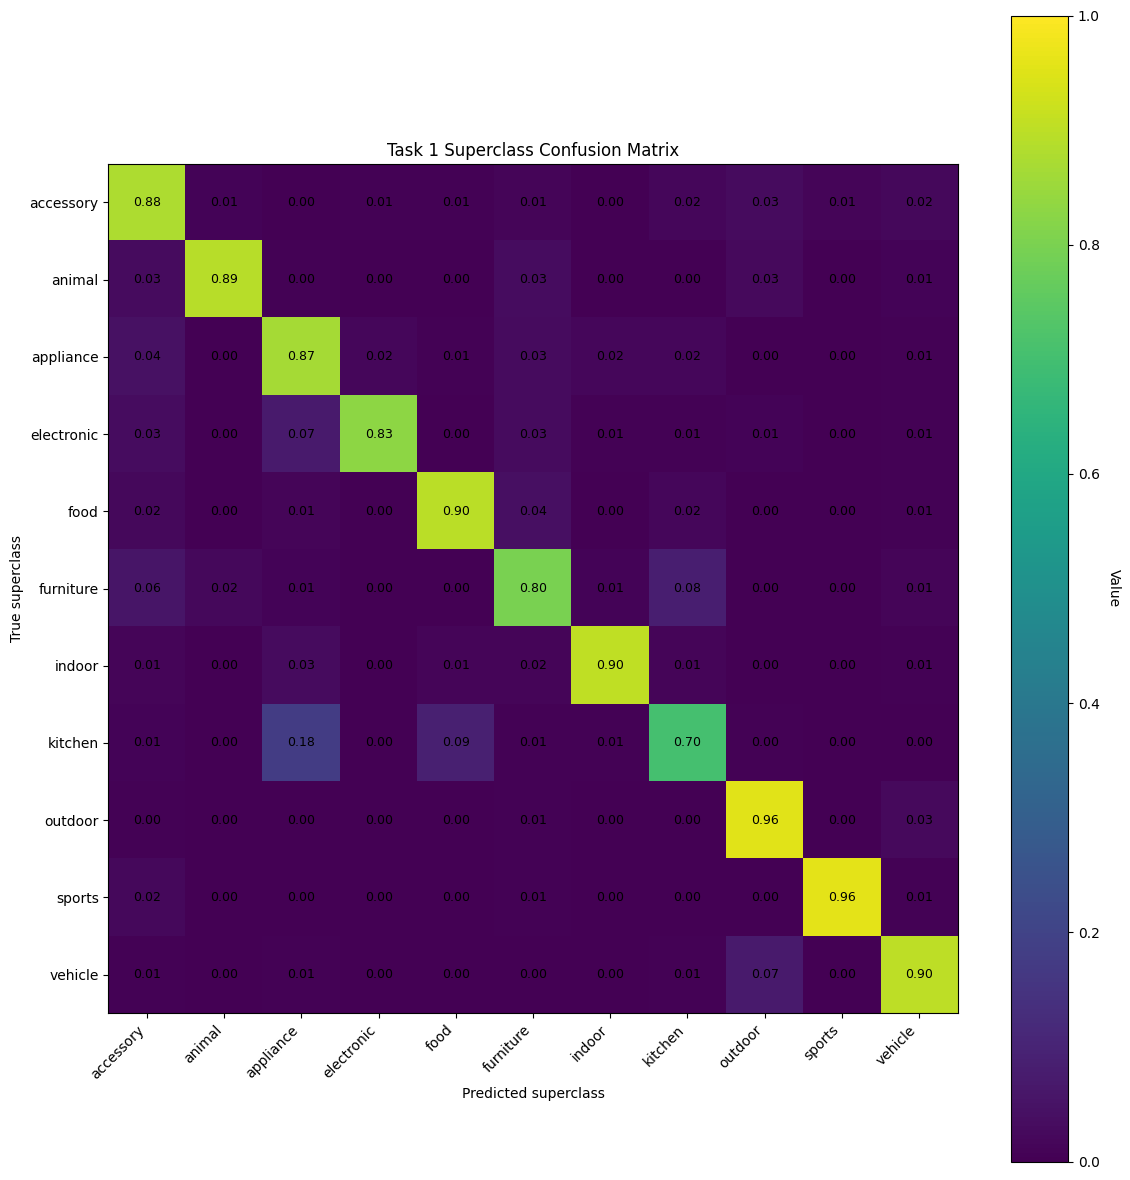

In [31]:
_, _, _ = run_incremental_fewshot(train_tasks[:2], k=15)
results, per_task_details = test_incremental_fewshot(test_tasks[:1])

summary_df = compact_summary_table(results, per_task_details)
print(summary_df)
print_task_report(per_task_details, 0)

   task  task_accuracy  mean_superclass_acc  std_superclass_acc
0     1         0.8495               0.8542              0.1012

================ TASK 1 ================


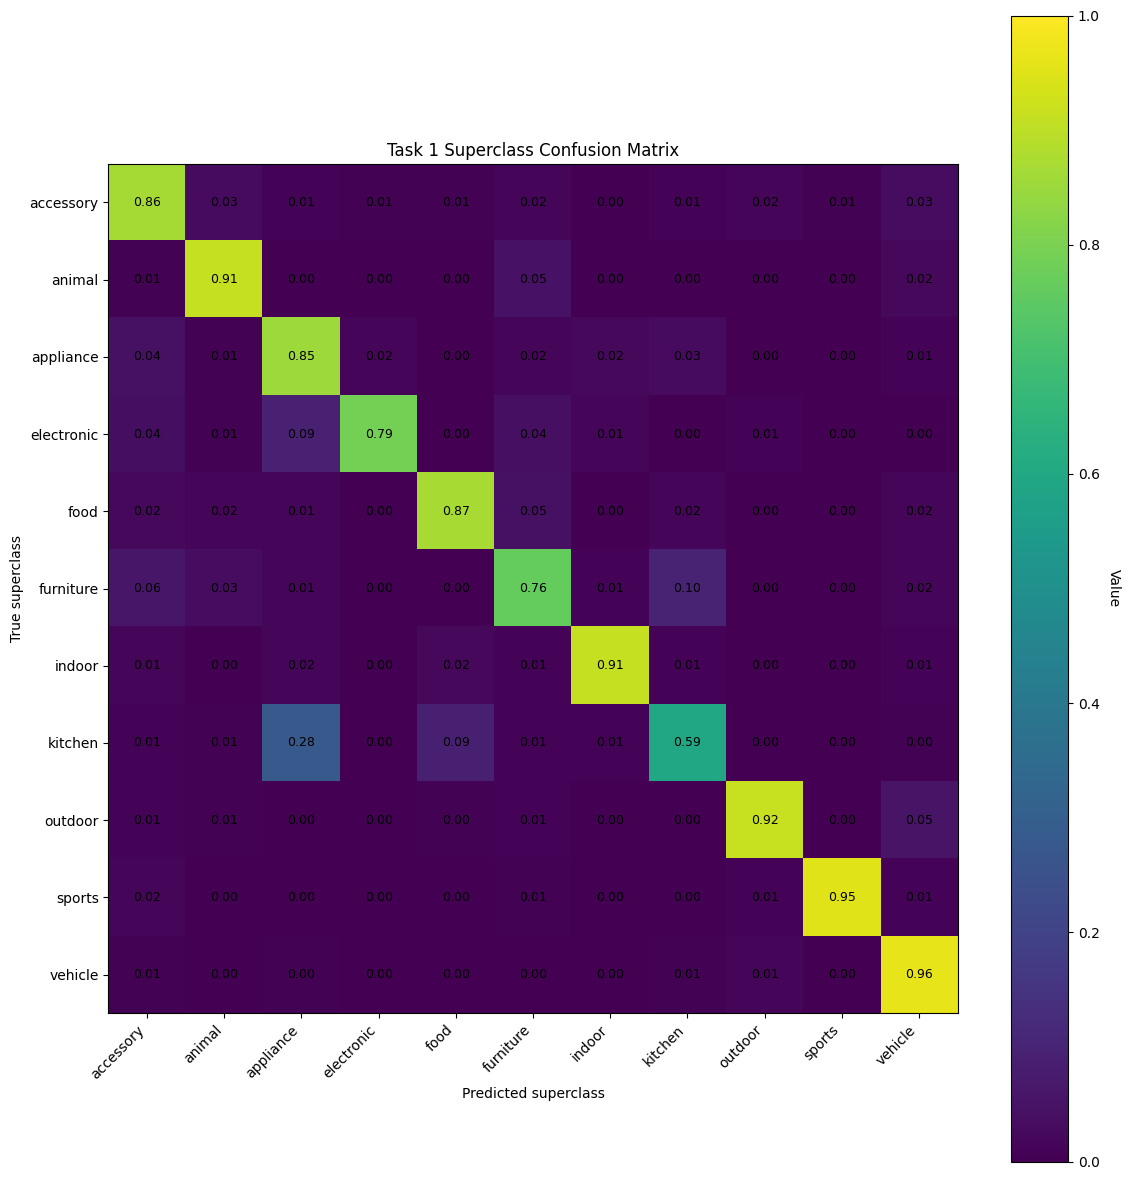

In [32]:
_, _, _ = run_incremental_fewshot(train_tasks[:3], k=15)
results, per_task_details = test_incremental_fewshot(test_tasks[:1])

summary_df = compact_summary_table(results, per_task_details)
print(summary_df)
print_task_report(per_task_details, 0)

   task  task_accuracy  mean_superclass_acc  std_superclass_acc
0     1         0.8927               0.8857              0.0661

================ TASK 1 ================


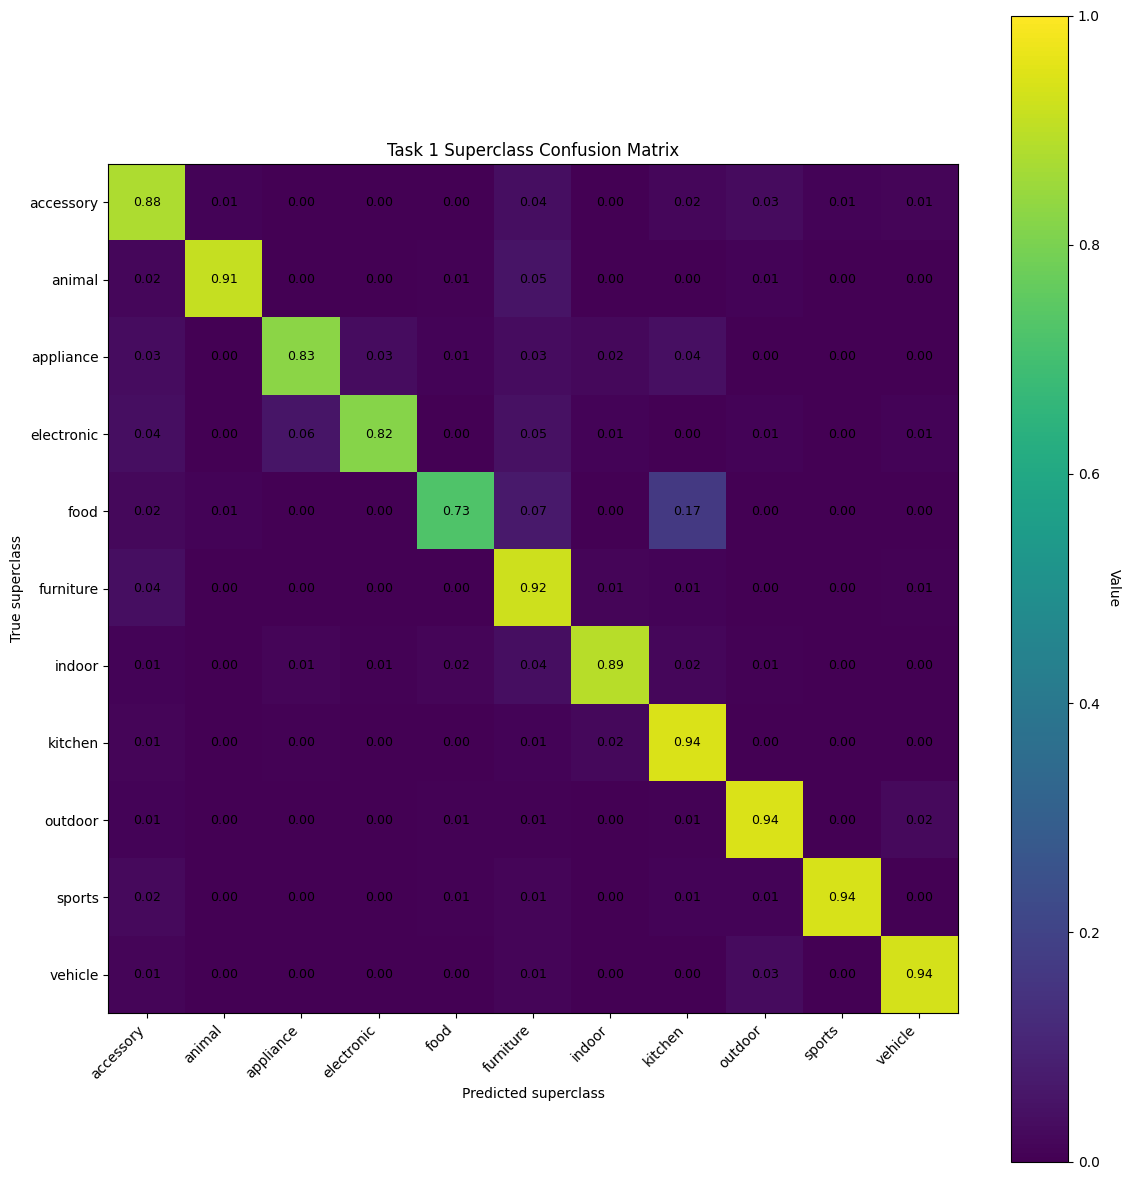

In [33]:
_, _, _ = run_incremental_fewshot(train_tasks, k=15)
results, per_task_details = test_incremental_fewshot(test_tasks[:1])

summary_df = compact_summary_table(results, per_task_details)
print(summary_df)
print_task_report(per_task_details, 0)

   task  task_accuracy  mean_superclass_acc  std_superclass_acc
0     1         0.8027               0.7999              0.0643

================ TASK 1 ================


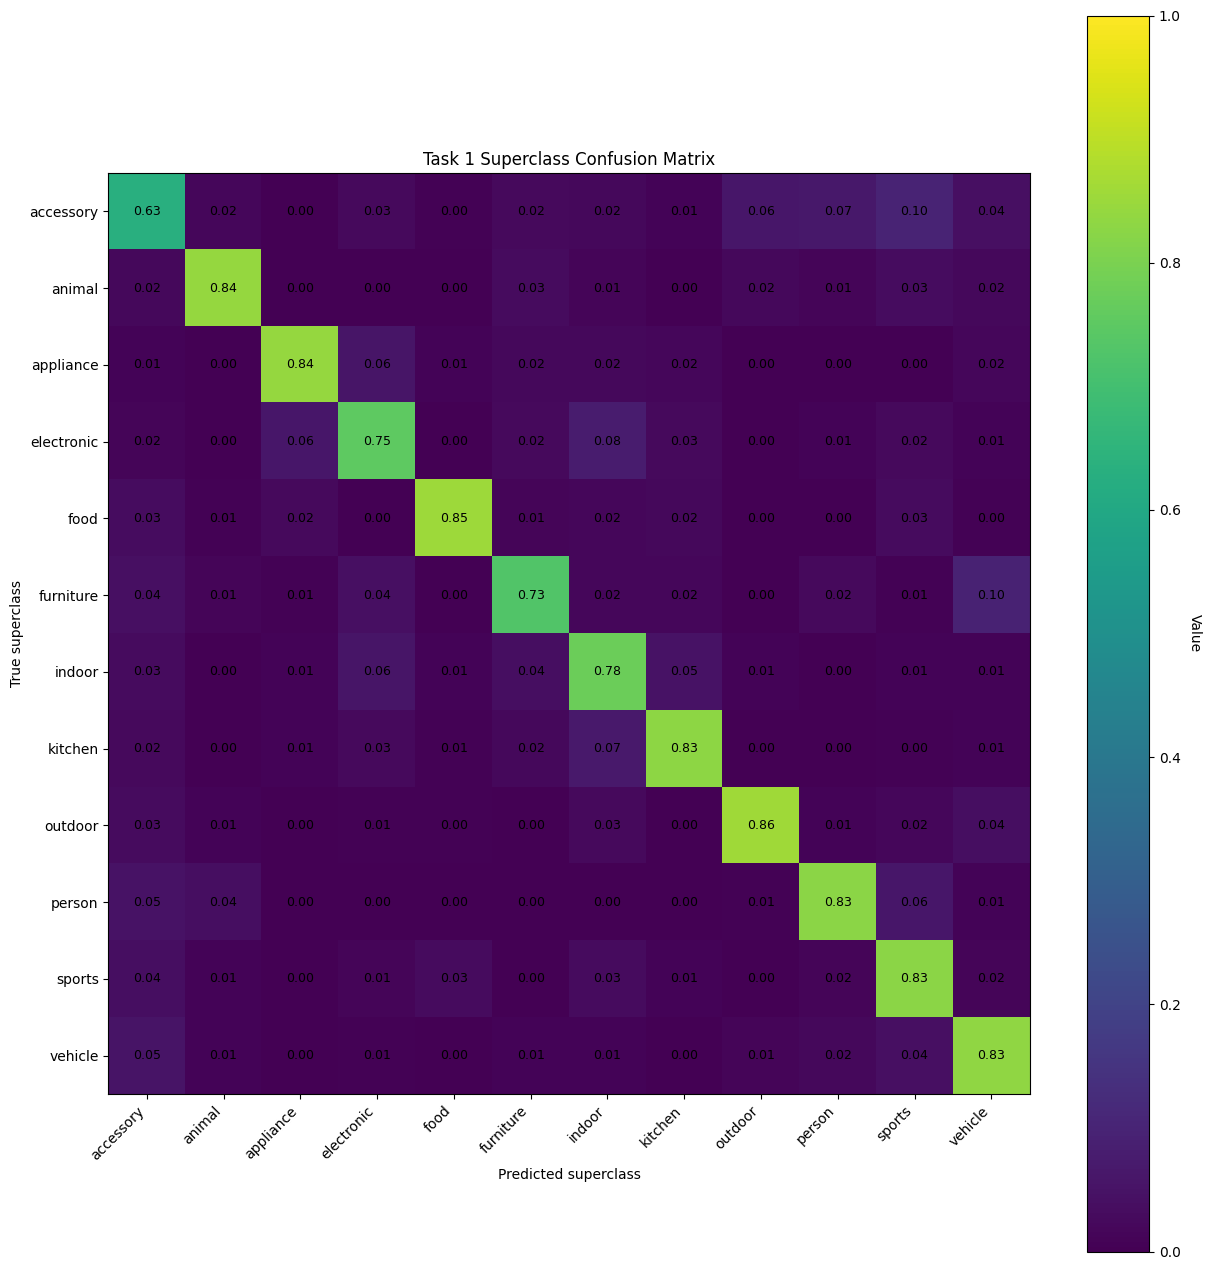

In [34]:
_, _, _ = run_incremental_fewshot(train_tasks[:2], k=15)
results, per_task_details = test_incremental_fewshot([test_tasks[1]])

summary_df = compact_summary_table(results, per_task_details)
print(summary_df)
print_task_report(per_task_details, 0)

   task  task_accuracy  mean_superclass_acc  std_superclass_acc
0     1         0.7964               0.7931              0.0806

================ TASK 1 ================


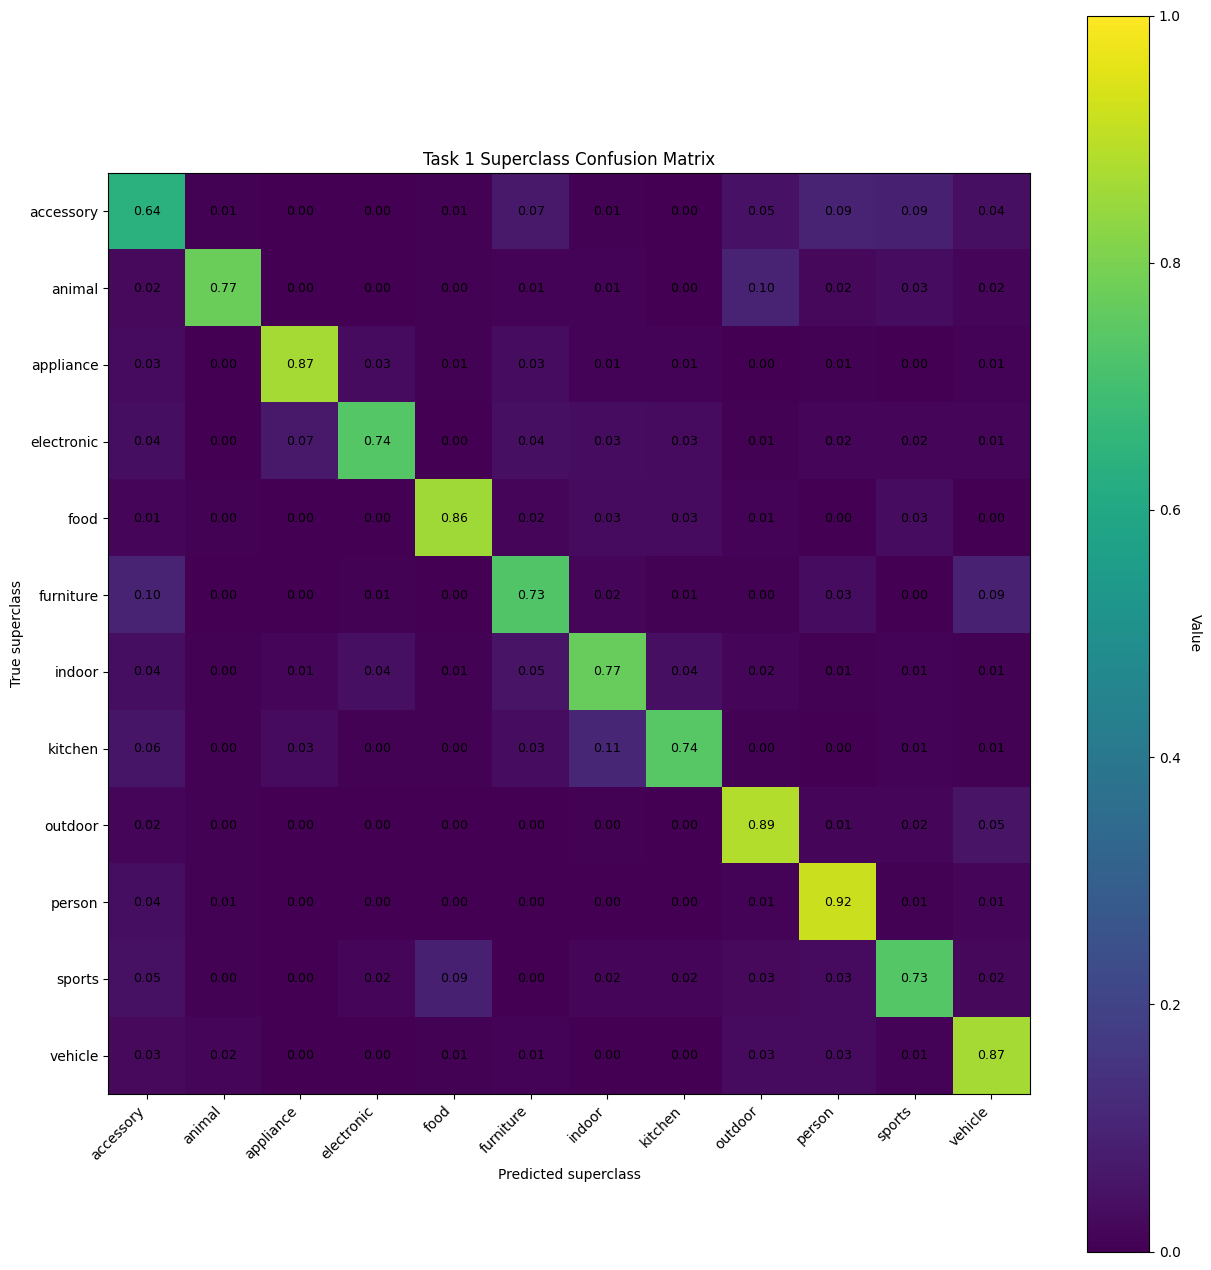

In [35]:
_, _, _ = run_incremental_fewshot(train_tasks[:3], k=15)
results, per_task_details = test_incremental_fewshot([test_tasks[1]])

summary_df = compact_summary_table(results, per_task_details)
print(summary_df)
print_task_report(per_task_details, 0)

   task  task_accuracy  mean_superclass_acc  std_superclass_acc
0     1         0.7677               0.7703              0.1027

================ TASK 1 ================


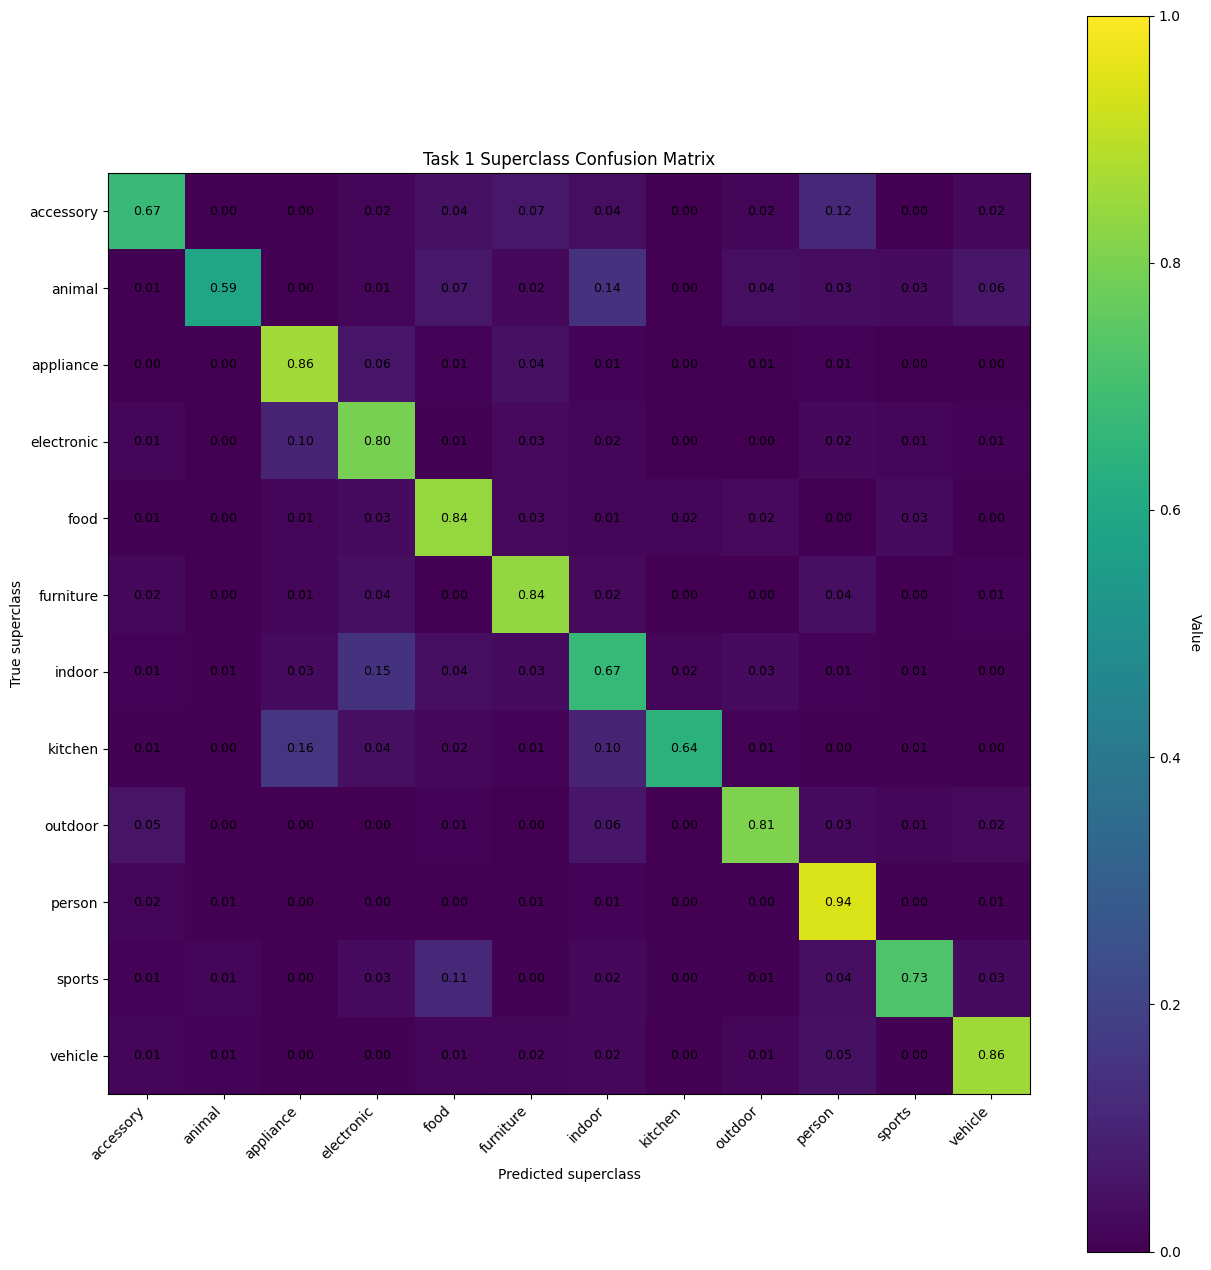

In [36]:
_, _, _ = run_incremental_fewshot(train_tasks, k=15)
results, per_task_details = test_incremental_fewshot([test_tasks[1]])

summary_df = compact_summary_table(results, per_task_details)
print(summary_df)
print_task_report(per_task_details, 0)

   task  task_accuracy  mean_superclass_acc  std_superclass_acc
0     1         0.7715               0.7727              0.0644

================ TASK 1 ================


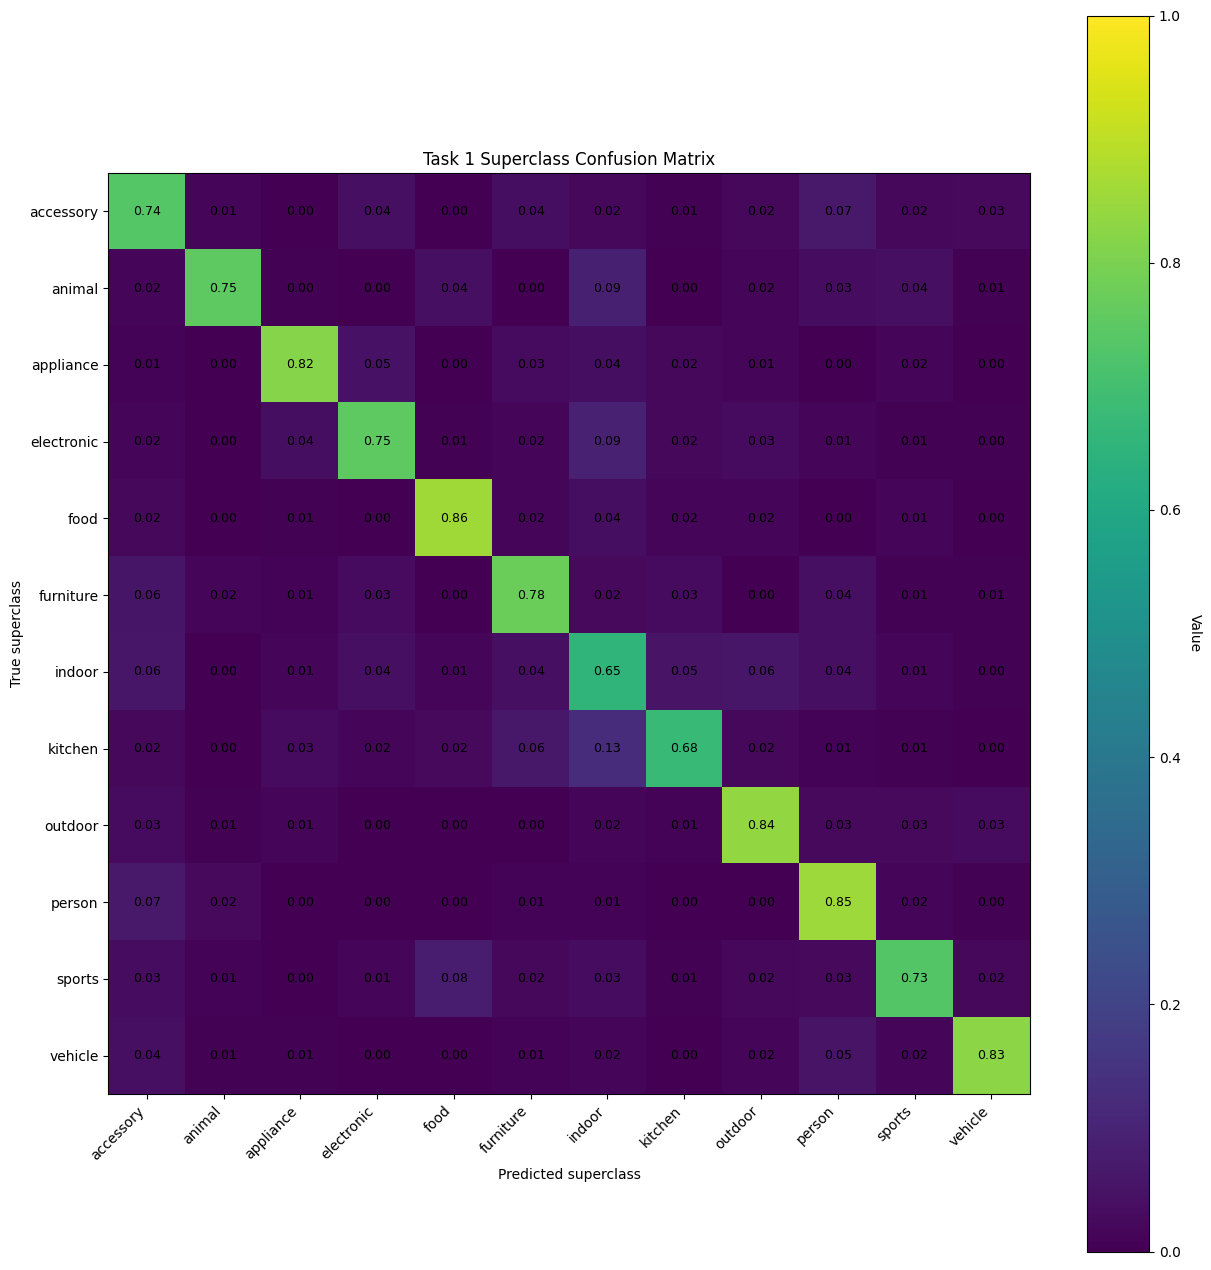

In [37]:
_, _, _ = run_incremental_fewshot(train_tasks[:3], k=15)
results, per_task_details = test_incremental_fewshot([test_tasks[2]])

summary_df = compact_summary_table(results, per_task_details)
print(summary_df)
print_task_report(per_task_details, 0)

   task  task_accuracy  mean_superclass_acc  std_superclass_acc
0     1         0.7213               0.7274              0.1129

================ TASK 1 ================


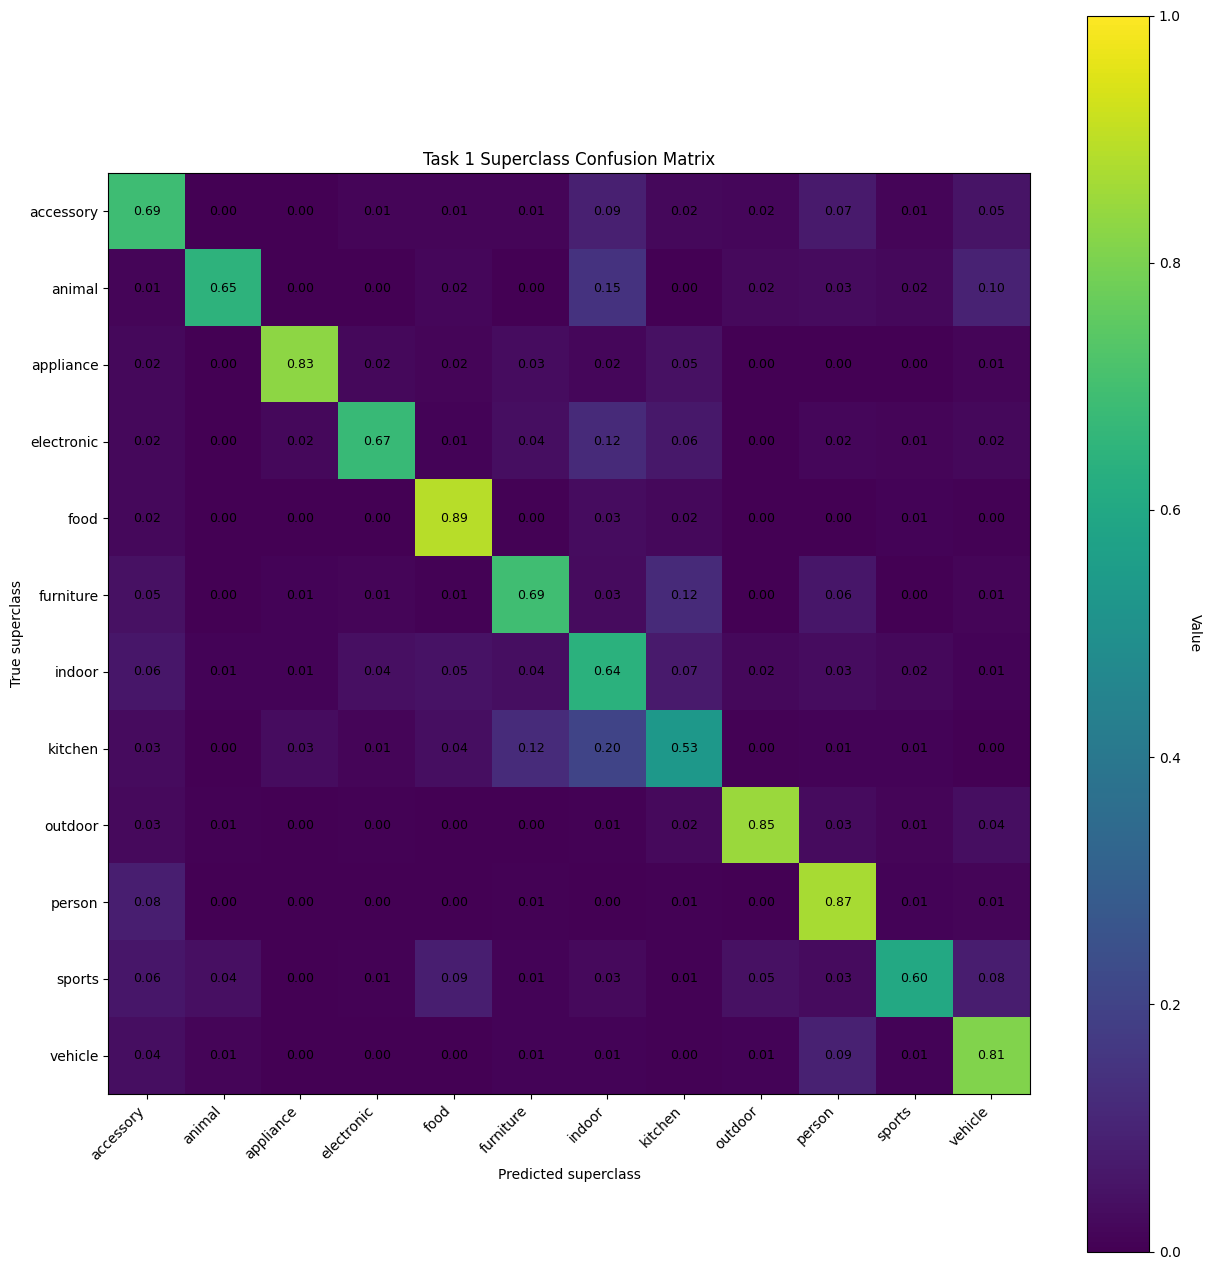

In [38]:
_, _, _ = run_incremental_fewshot(train_tasks, k=15)
results, per_task_details = test_incremental_fewshot([test_tasks[2]])

summary_df = compact_summary_table(results, per_task_details)
print(summary_df)
print_task_report(per_task_details, 0)

   task  task_accuracy  mean_superclass_acc  std_superclass_acc
0     1         0.7345               0.7254              0.0999

================ TASK 1 ================


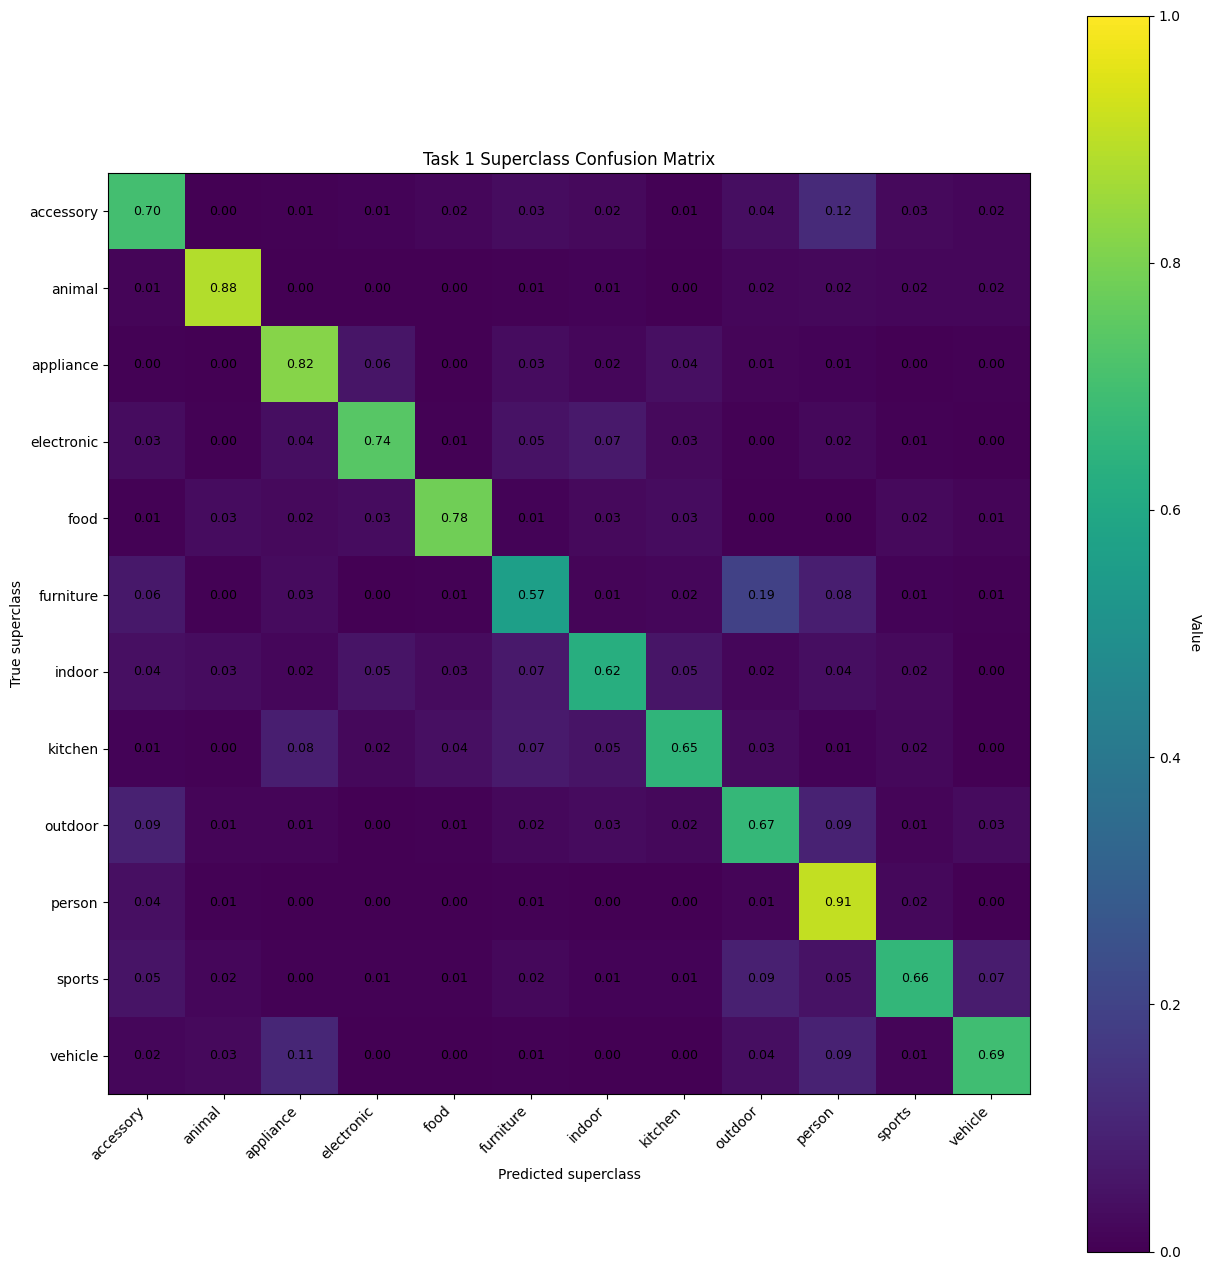

In [39]:
_, _, _ = run_incremental_fewshot(train_tasks, k=15)
results, per_task_details = test_incremental_fewshot([test_tasks[3]])

summary_df = compact_summary_table(results, per_task_details)
print(summary_df)
print_task_report(per_task_details, 0)

w/k-medoids


    T1      T2      T3      T4          forgetting
T1  0.9141  0.9152  0.8758  0.6005      0.3136

T2  -----   0.8539  0.7856  0.7784      0.0755

T3  -----   -----   0.7705  0.7766      -0.0071

T4  -----   -----   -----   0.7829      0.0000


=== Forgetting Matrix (macro superclass accuracy) ===
                      T1      T2      T3      T4
Trained up to T1  0.8946     NaN     NaN     NaN
Trained up to T2  0.8710  0.7999     NaN     NaN
Trained up to T3  0.8542  0.7931  0.7727     NaN
Trained up to T4  0.8857  0.7703  0.7274  0.7254

=== Per-task Forgetting (diag - final row) ===
  T1: 0.8946 → 0.8857  (forgetting = +0.0089)
  T2: 0.7999 → 0.7703  (forgetting = +0.0296)
  T3: 0.7727 → 0.7274  (forgetting = +0.0452)
  T4: 0.7254 → 0.7254  (forgetting = +0.0000)

=== Confusion Matrices ===


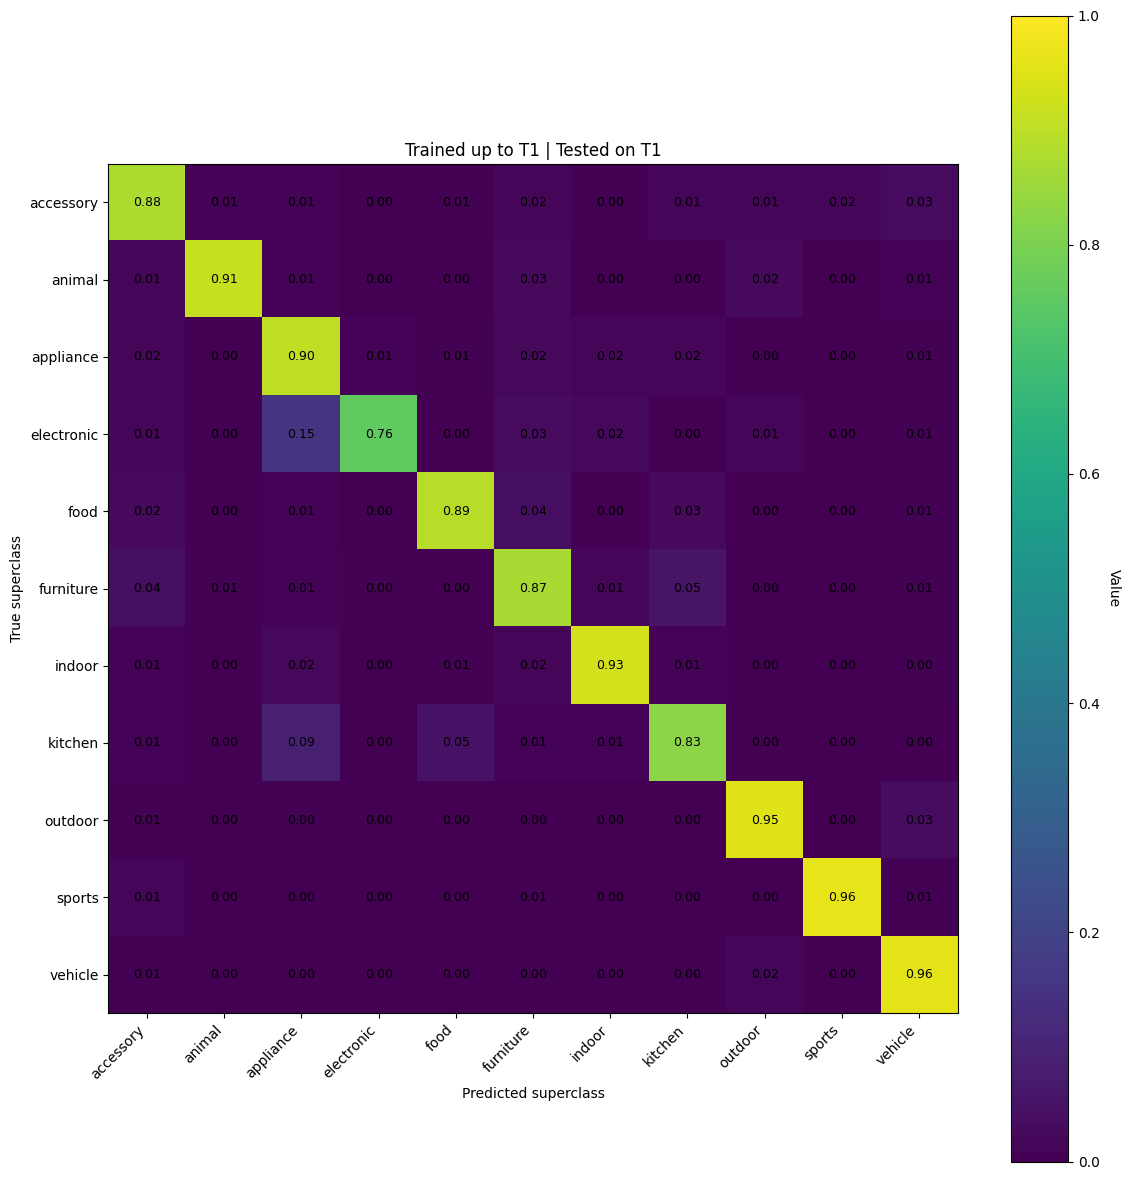

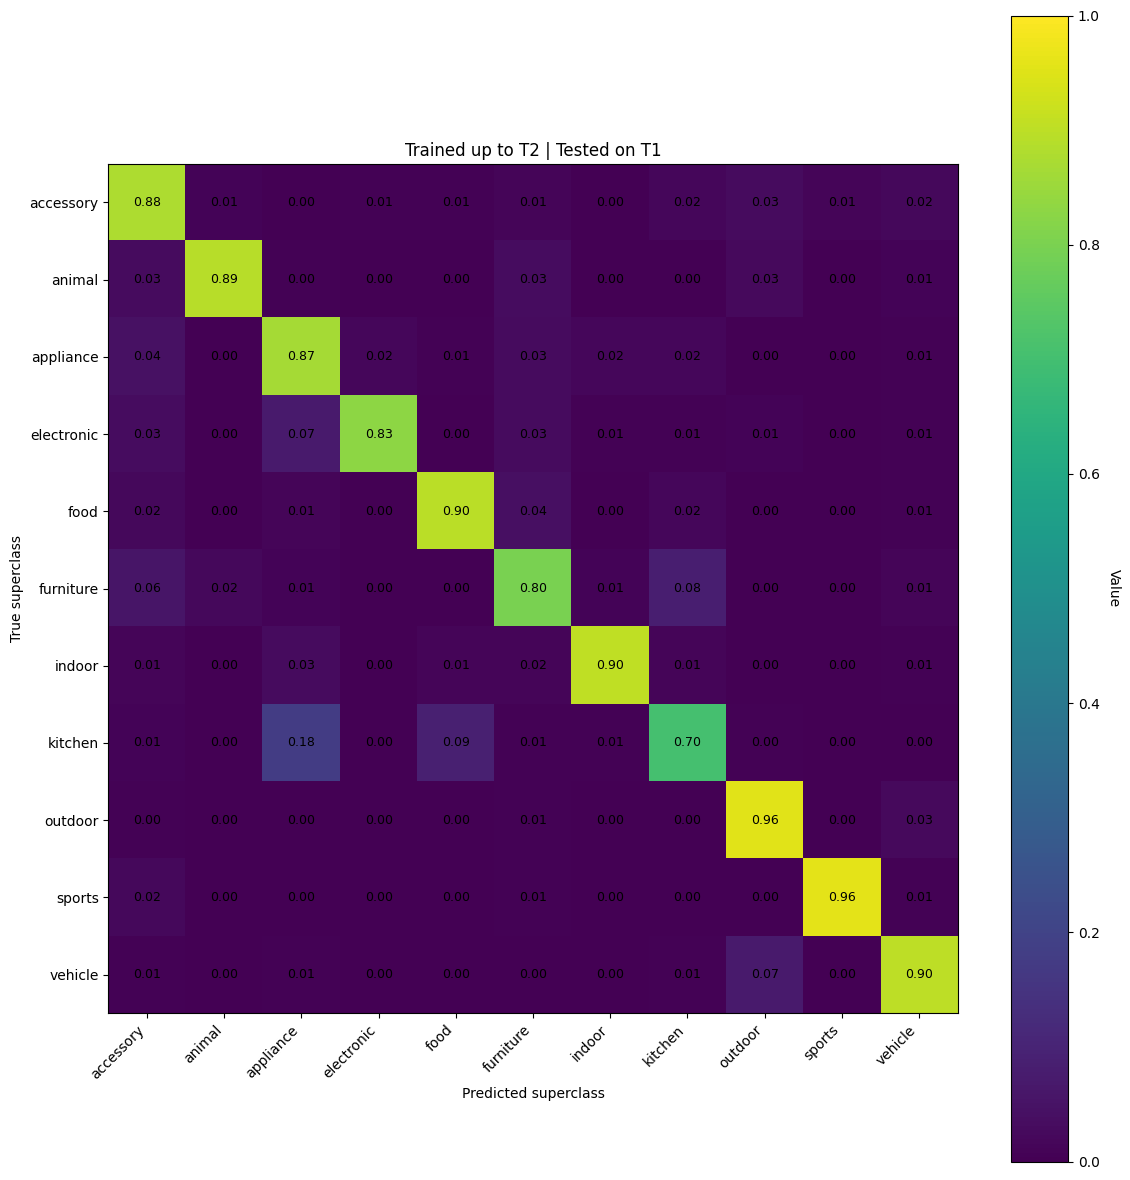

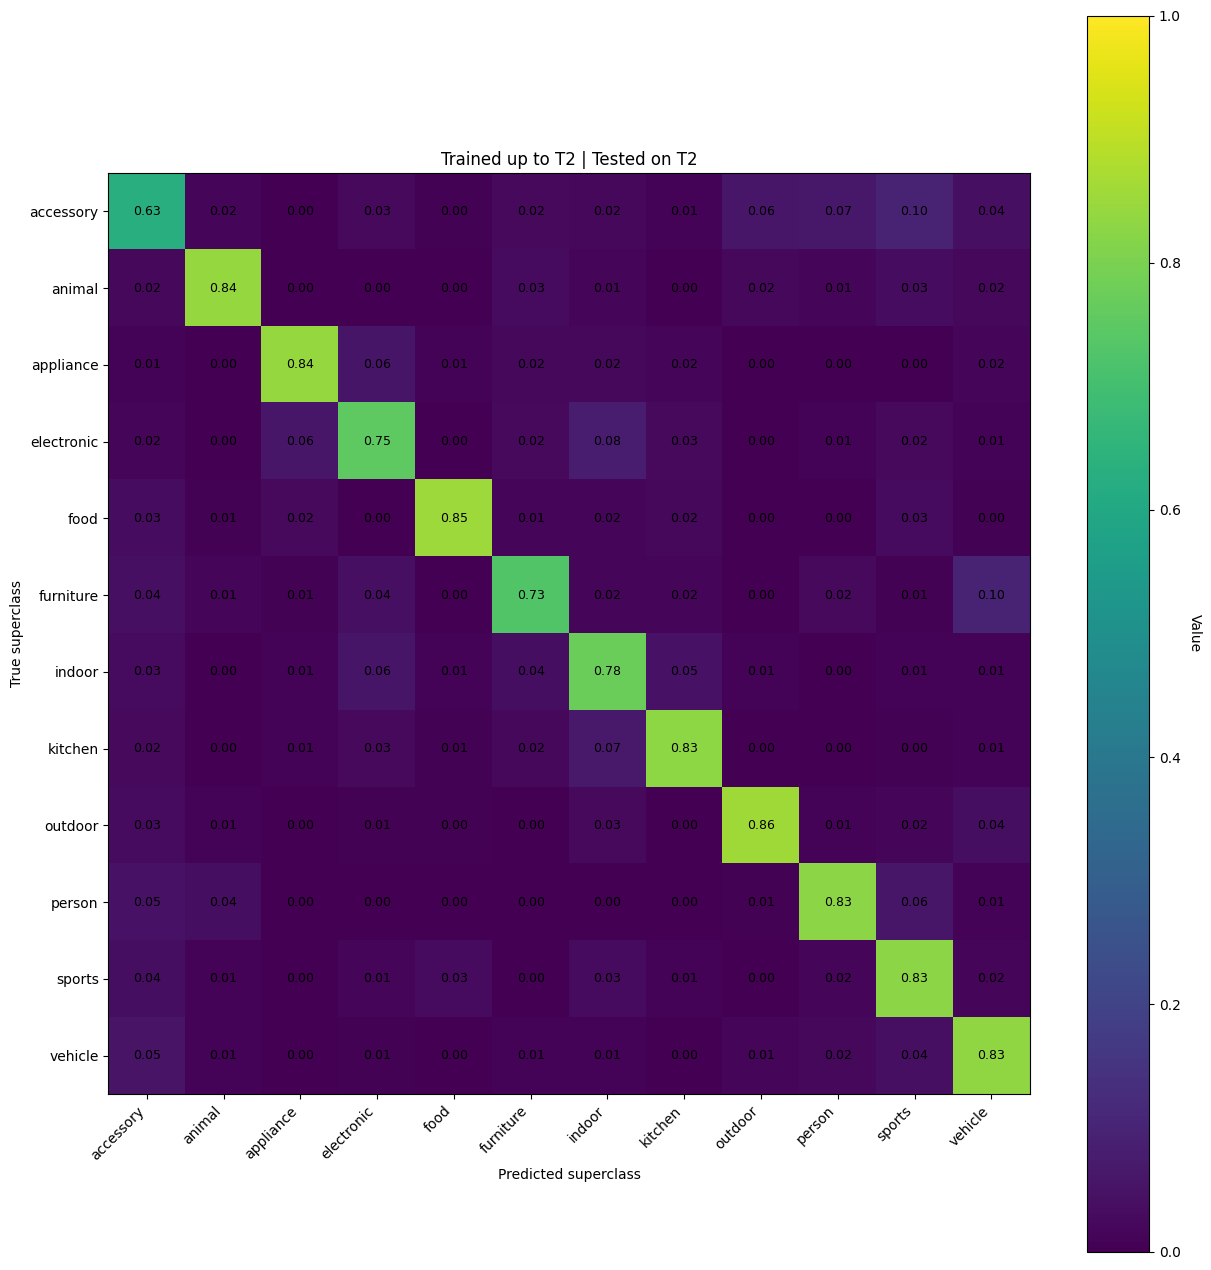

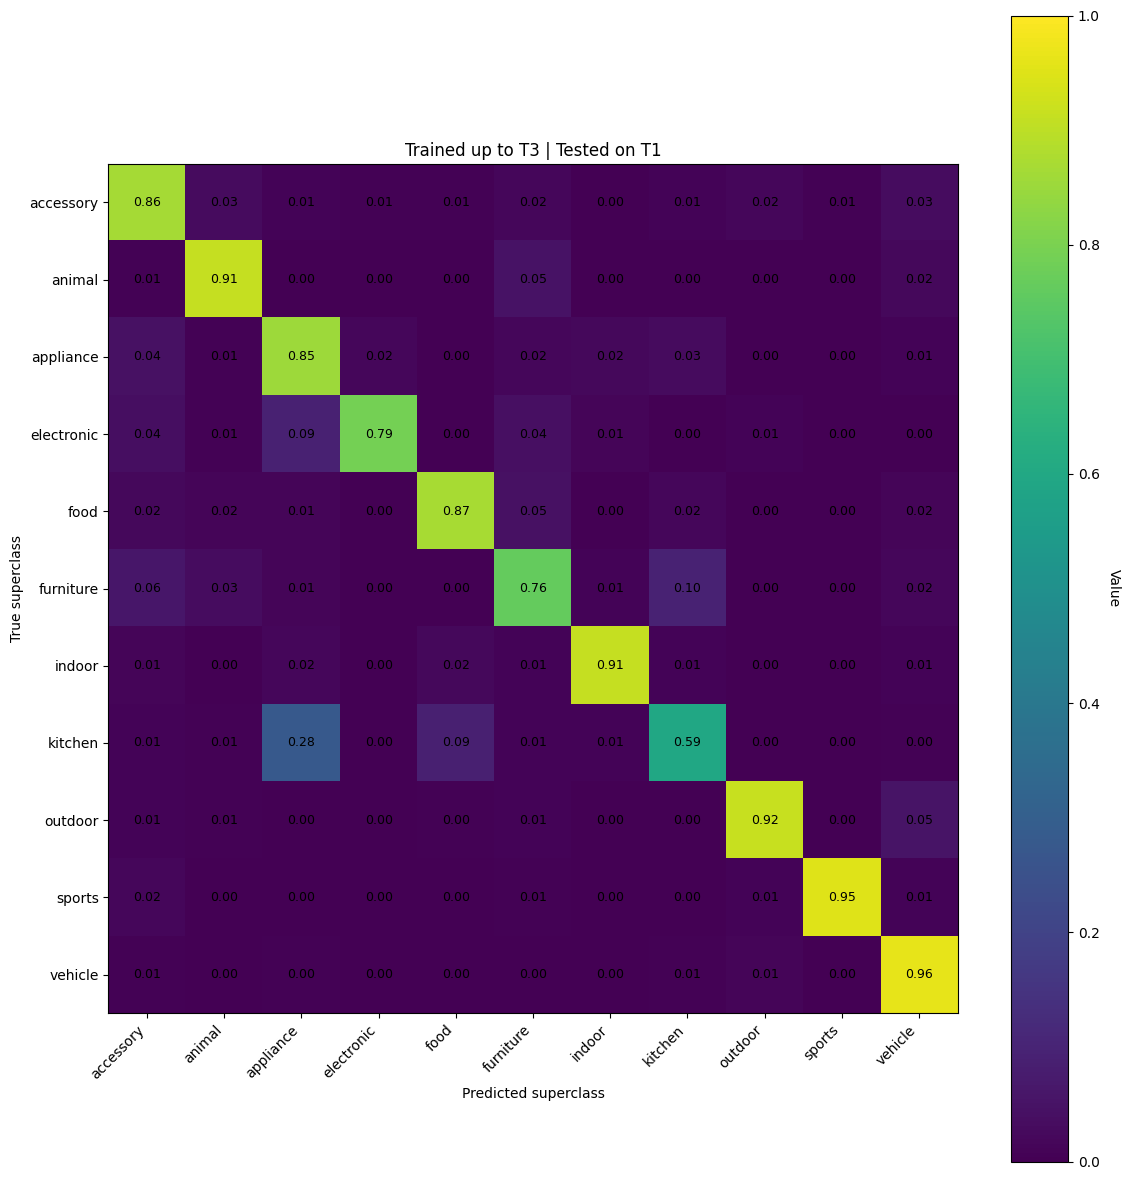

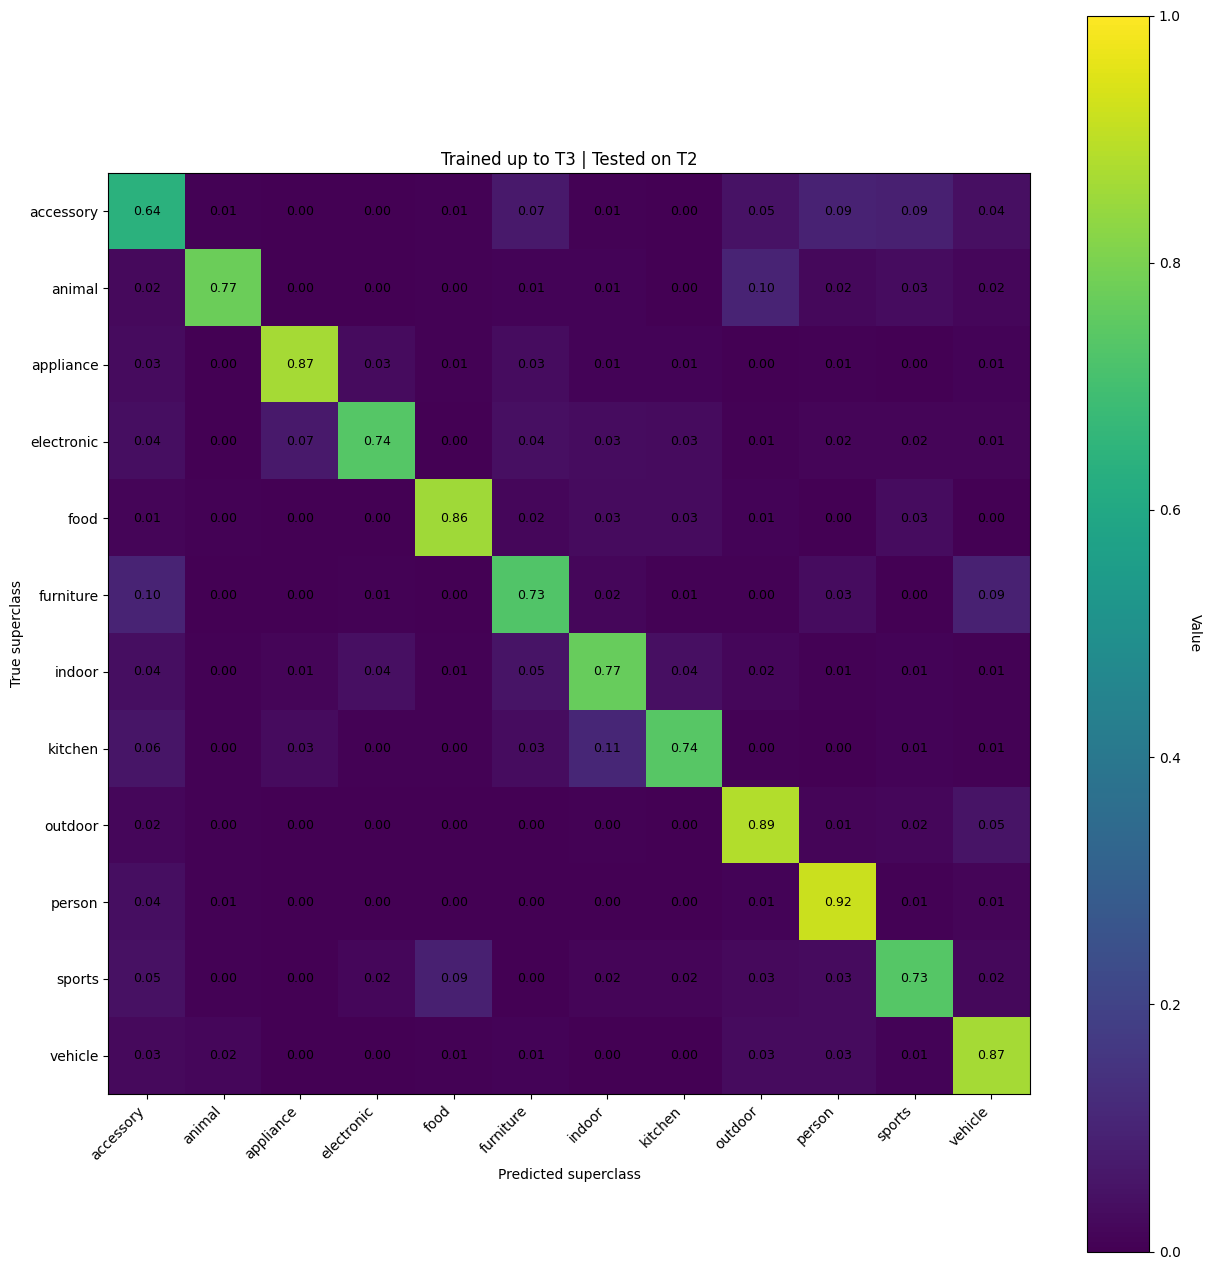

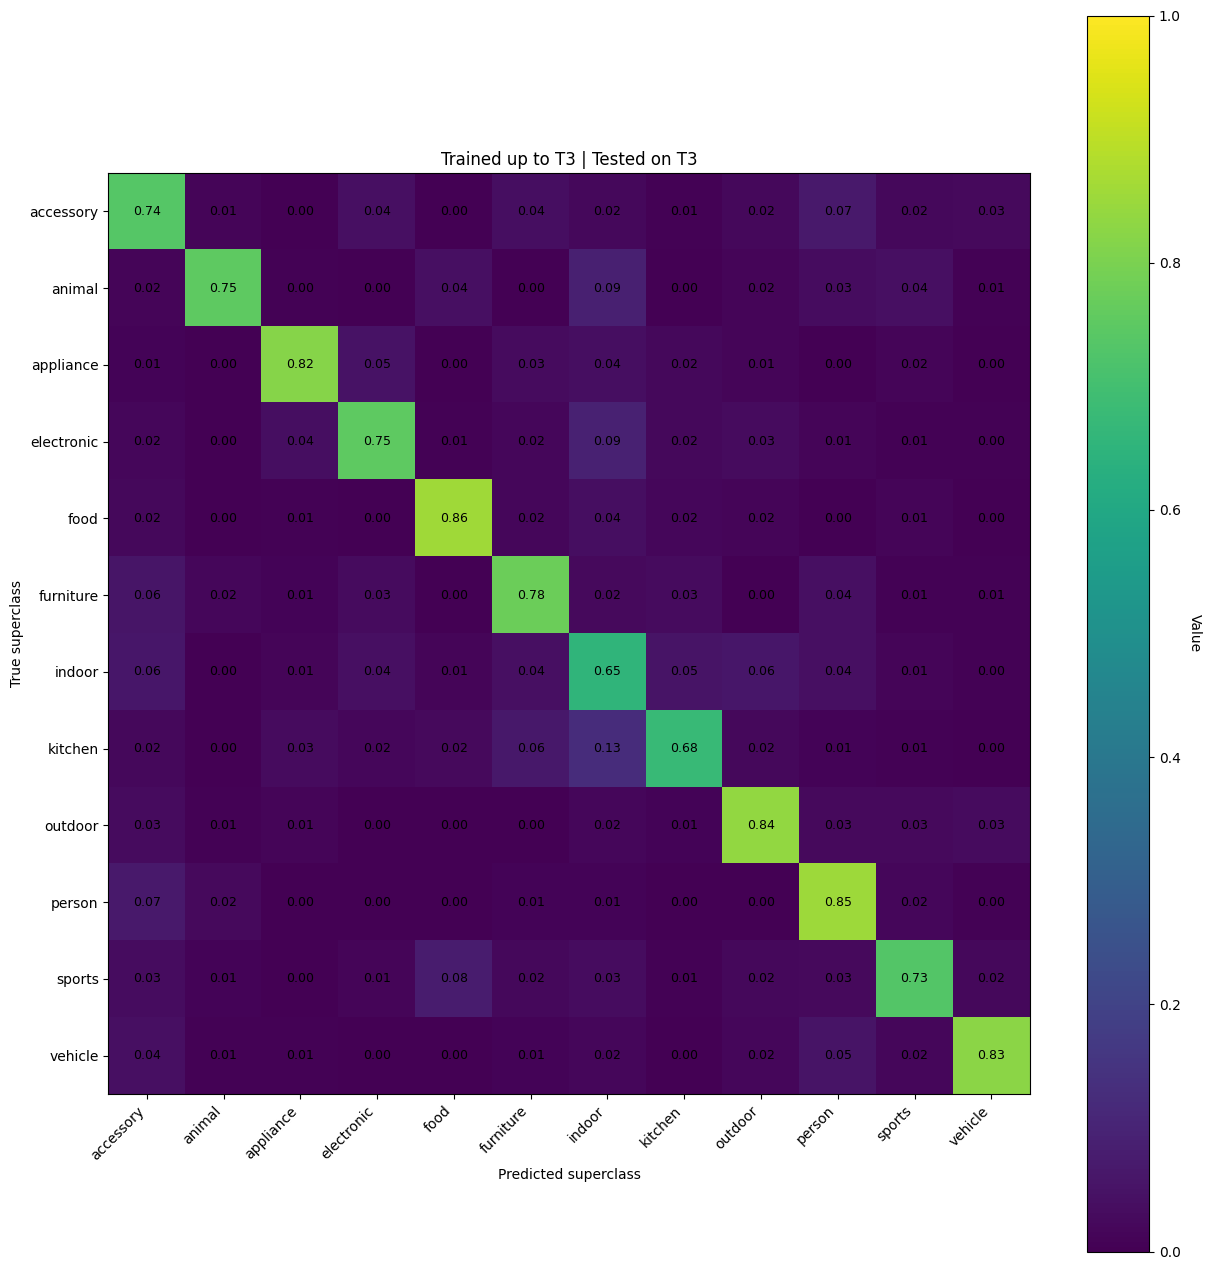

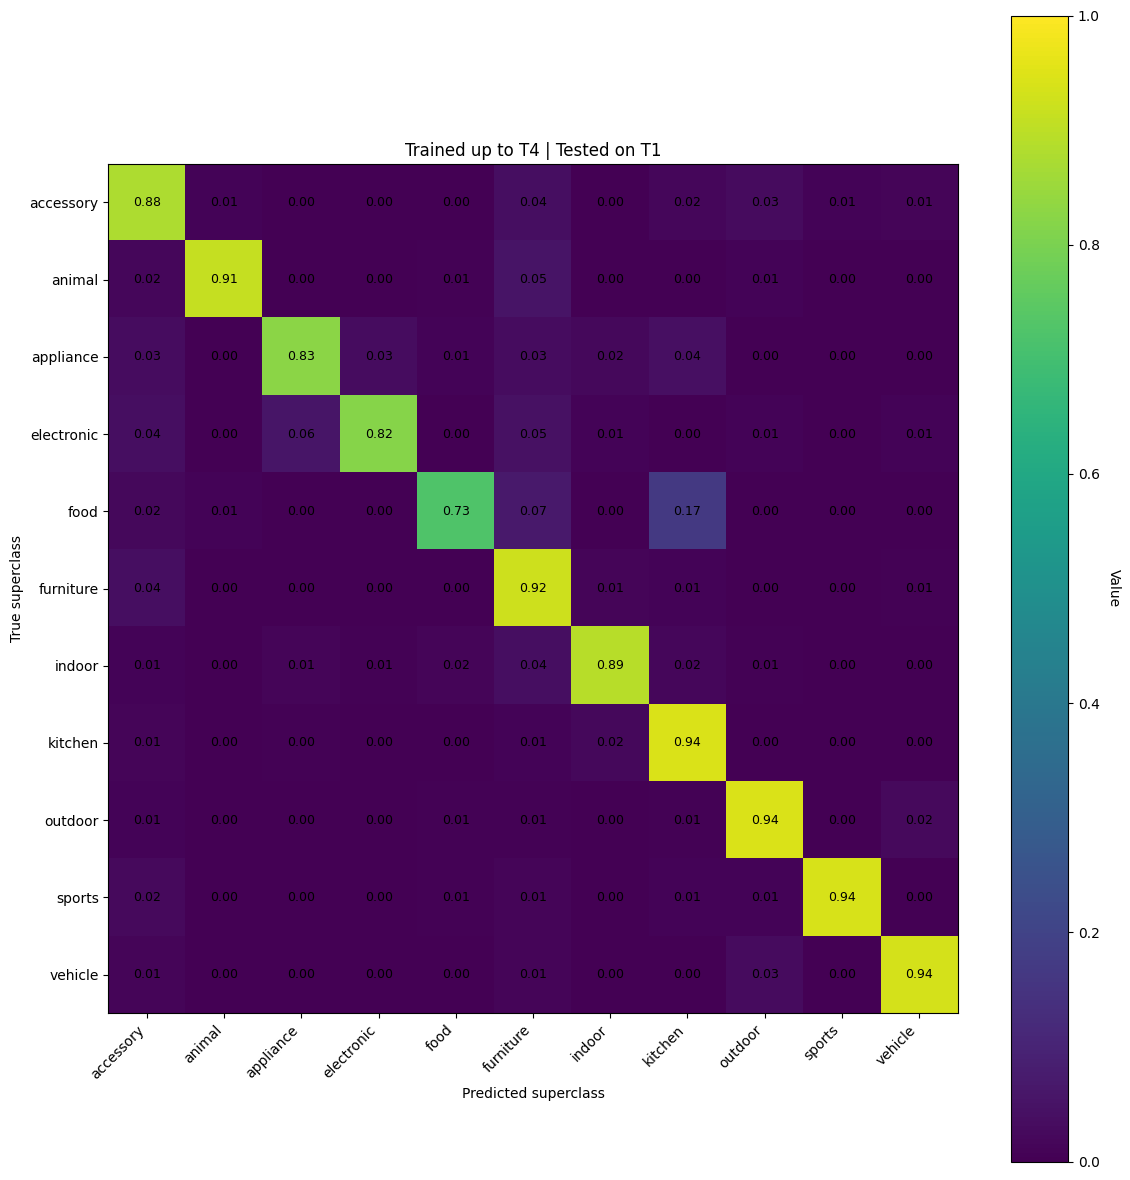

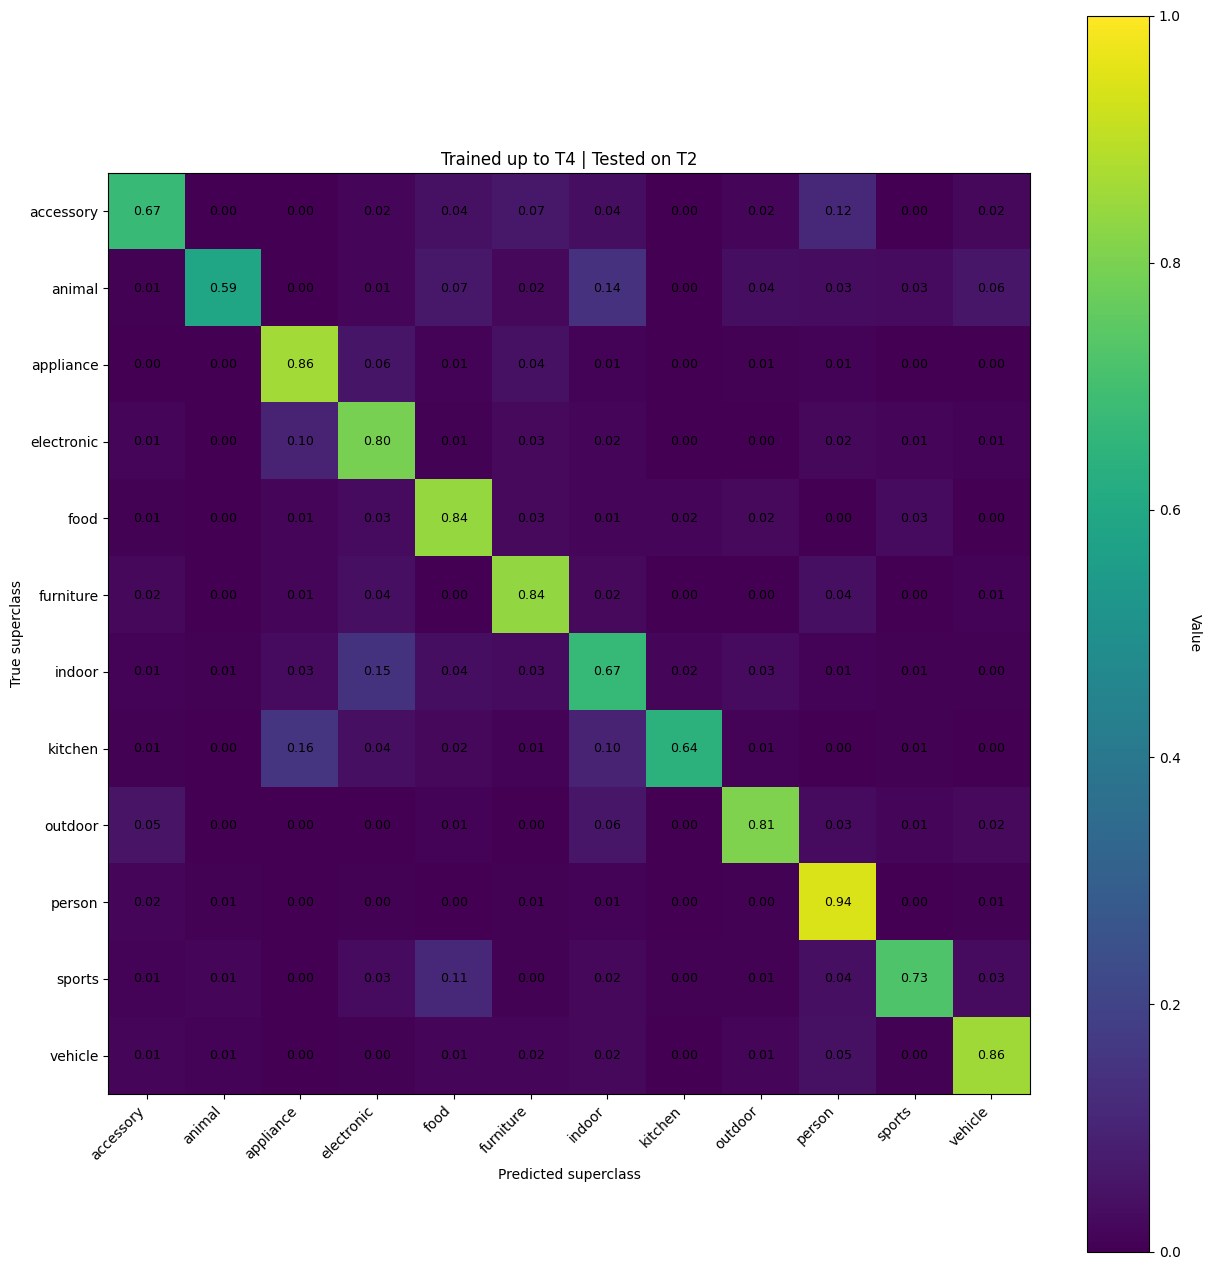

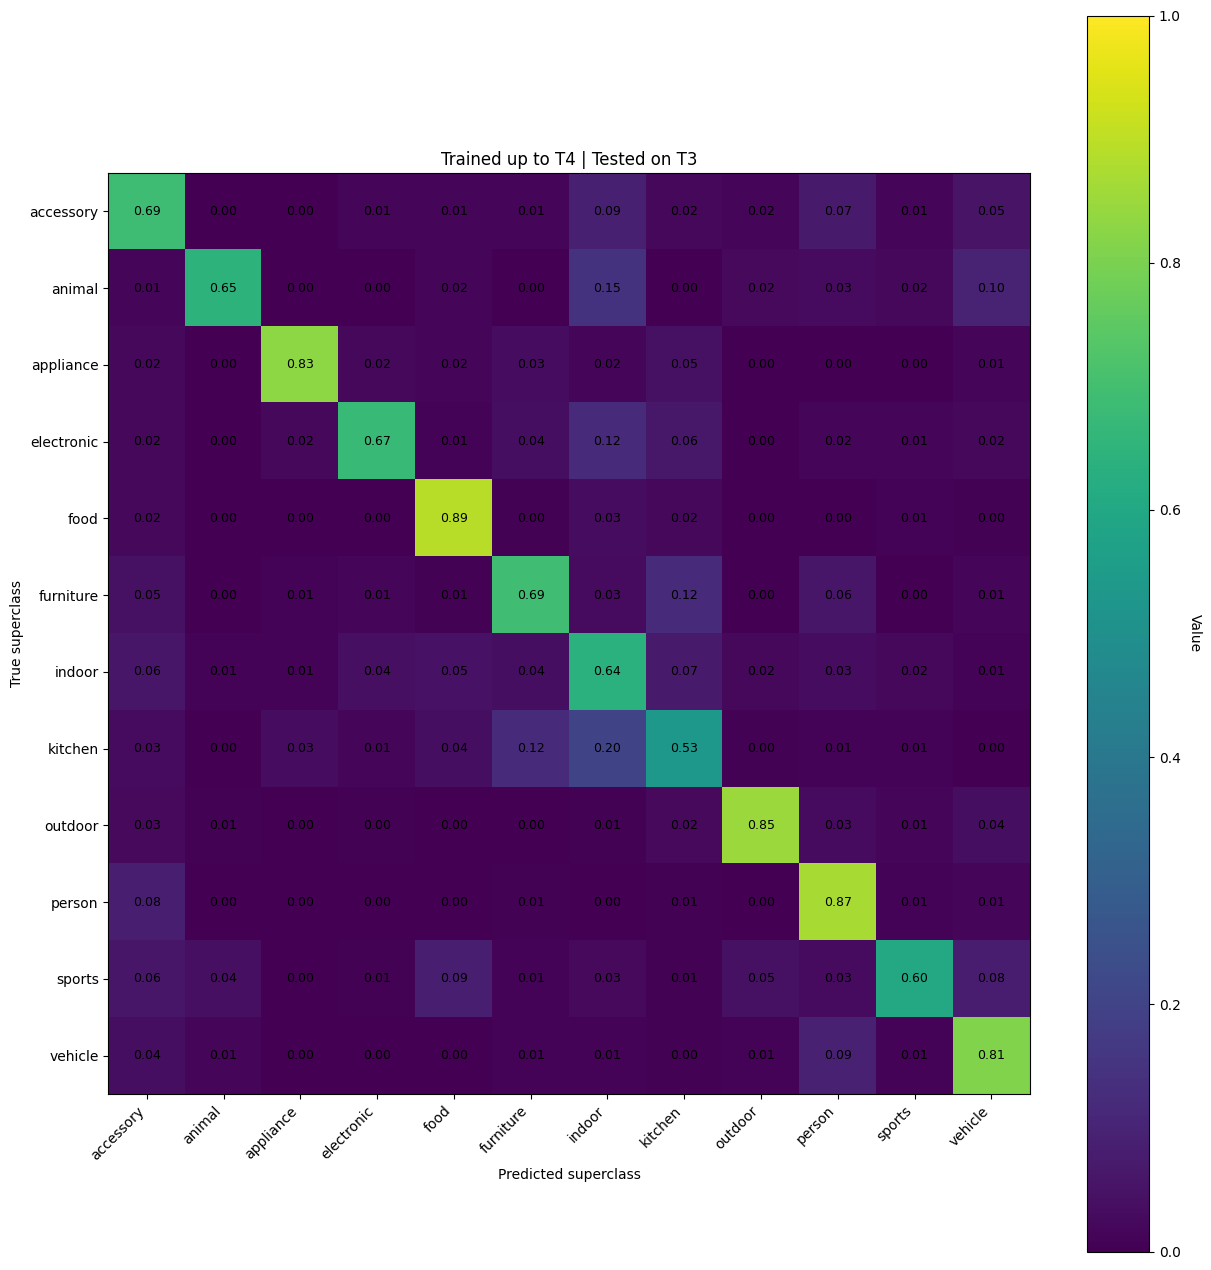

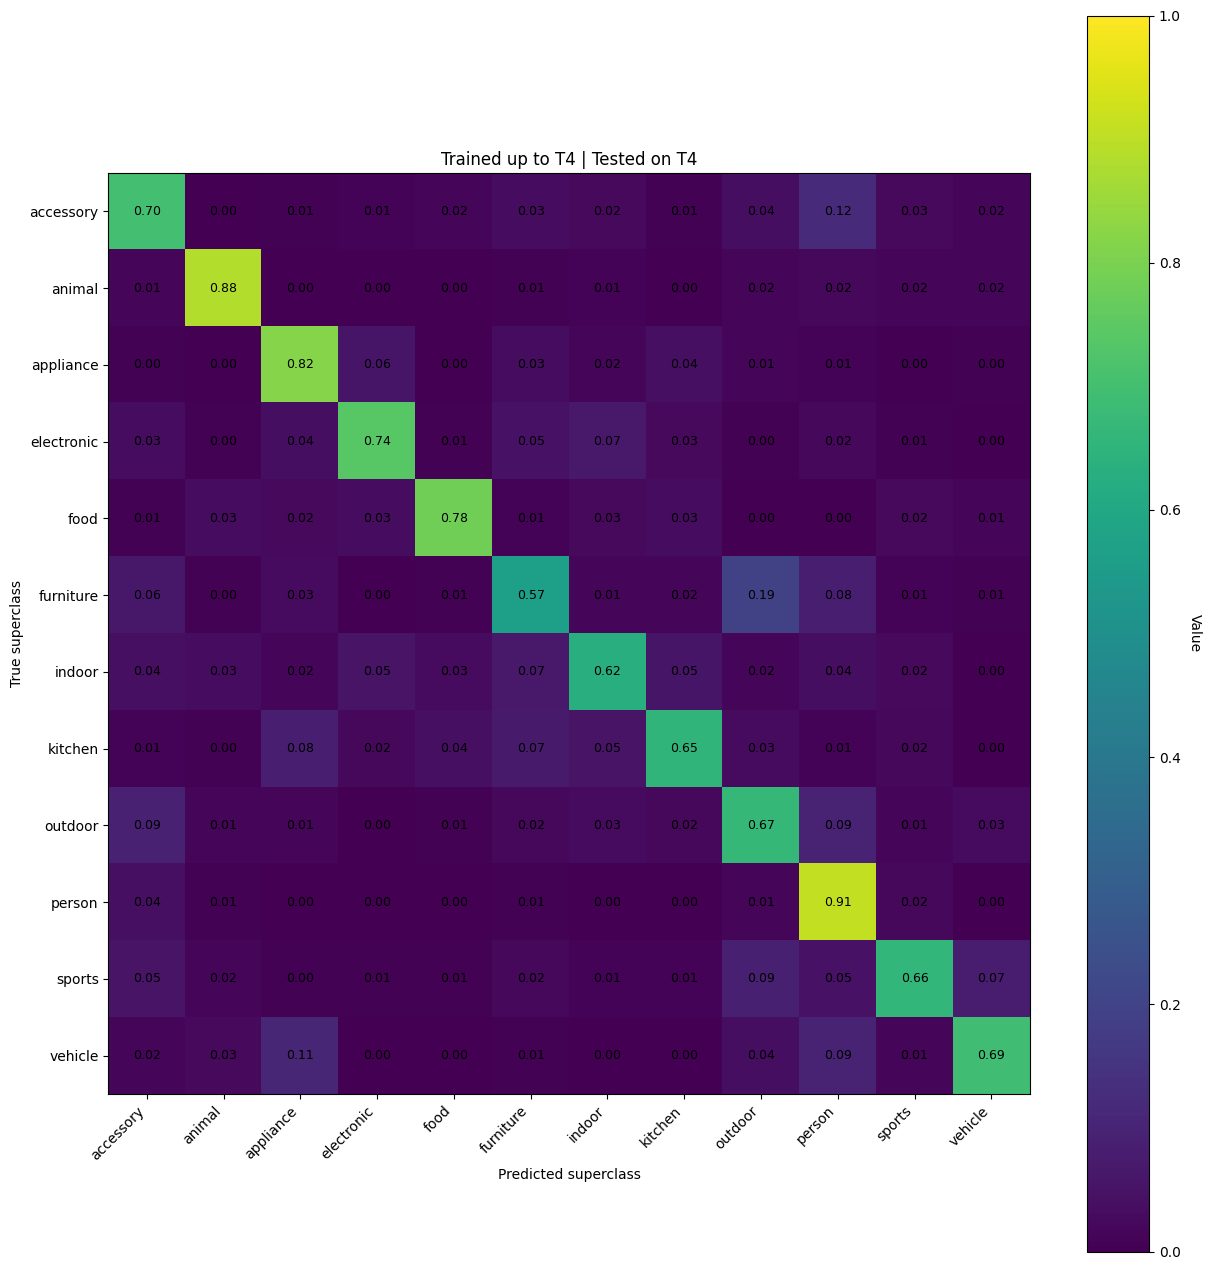

In [ ]:
n_tasks = len(train_tasks)
forgetting_matrix = np.full((n_tasks, n_tasks), np.nan)
confusion_store   = {}

for train_up_to in range(1, n_tasks + 1):
    _, _, _ = run_incremental_fewshot(train_tasks[:train_up_to], k=15)

    for test_task_idx in range(train_up_to): 
        test_emb, test_sc = test_tasks[test_task_idx]
        res, det = test_incremental_fewshot([(test_emb, test_sc)])

        acc = res[0]["macro_superclass_acc"]
        forgetting_matrix[train_up_to - 1, test_task_idx] = acc
        confusion_store[(train_up_to, test_task_idx + 1)] = {"y_true": det[0]["y_true"], "y_pred": det[0]["y_pred"]}

col_headers = [f"T{j+1}" for j in range(n_tasks)]
row_headers = [f"Trained up to T{i+1}" for i in range(n_tasks)]

fm_df = pd.DataFrame(np.round(forgetting_matrix, 4), index=row_headers, columns=col_headers)

print("\nForgetting Matrix")
print(fm_df.to_string())

print("\nPer-task Forgetting")
for j in range(n_tasks):
    diag_acc = forgetting_matrix[j, j]
    final_acc = forgetting_matrix[n_tasks - 1, j]
    print(f"  T{j+1}: {diag_acc:.4f} -> {final_acc:.4f}  (forgetting: {diag_acc - final_acc:+.4f})")

print("\nConfusion Matrices ")
for (train_up_to, test_task), data in sorted(confusion_store.items()):
    title = f"Trained up to T{train_up_to} | Tested on T{test_task}"
    show_confusion_matrix_image(data["y_true"], data["y_pred"], title=title)